# Patient Similarity Network + Agent-Based Modelling for Hospital Readmission

## Final Staff Presentation Notebook

**Dataset:** Diabetes 130-US Hospitals for Years 1999–2008



**Problem → Data → Patient representation → Leakage control → Similarity → Network → SNA → Prediction → ABM → Intervention → Robustness → Final evidence**



# 1. Problem Statement

Hospital readmission is not only an individual-risk problem. Patients can also be organized by **clinical similarity**.

### Research question

> **How can patient similarity network structure be used with agent-based modelling to identify high-priority patient groups and evaluate targeted interventions for reducing hospital readmission?**

### Objectives

1. Create a leakage-safe patient-level representation.
2. Construct and validate a weighted patient similarity network.
3. Use SNA to identify important nodes and clinically similar communities.
4. Build an agent-based readmission model.
5. Compare no intervention, random, risk-based and network-informed targeting.
6. Evaluate outcomes, efficiency and robustness.



In [1]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, Image

warnings.filterwarnings("ignore")

def find_root():
    candidates = [Path.cwd(), Path.cwd().parent,
                  Path.home()/"Desktop"/"sna",
                  Path.home()/"OneDrive"/"Desktop"/"sna"]
    for p in candidates:
        p = p.resolve()
        if (p/"results").exists() and (p/"figures").exists():
            return p
    for p in Path.cwd().resolve().parents:
        if (p/"results").exists() and (p/"figures").exists():
            return p
    raise FileNotFoundError("Open this notebook inside the sna project.")

PROJECT_ROOT = find_root()
RESULTS = PROJECT_ROOT/"results"
FIGURES = PROJECT_ROOT/"figures"

def csv(name):
    p = RESULTS/name
    return pd.read_csv(p) if p.exists() else None

def js(name):
    p = RESULTS/name
    if not p.exists(): return None
    with open(p, encoding="utf-8") as f:
        return json.load(f)

print("Project:", PROJECT_ROOT)
print("Results:", RESULTS)
print("Figures:", FIGURES)

Project: C:\Users\Gayatri\OneDrive\Desktop\sna
Results: C:\Users\Gayatri\OneDrive\Desktop\sna\results
Figures: C:\Users\Gayatri\OneDrive\Desktop\sna\figures


# 2. End-to-End Project Flow


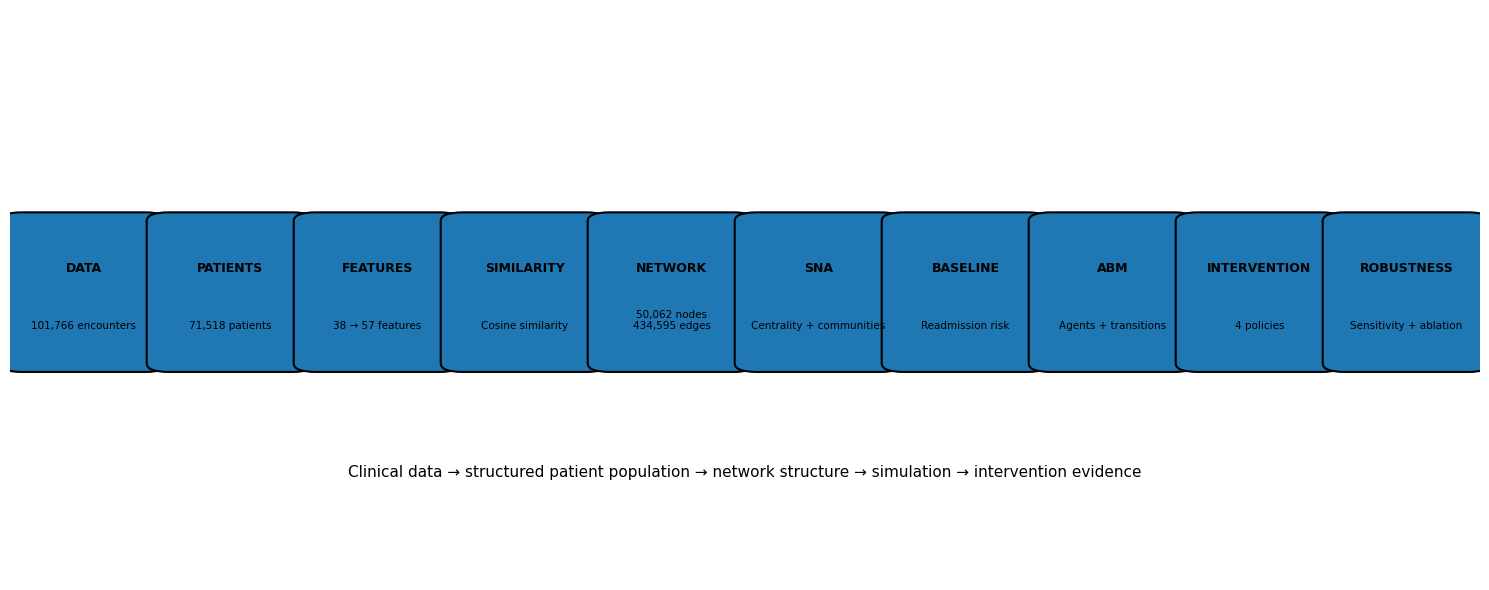

In [2]:
fig, ax = plt.subplots(figsize=(15,6))
ax.axis("off")
steps = [
("DATA","101,766 encounters"),
("PATIENTS","71,518 patients"),
("FEATURES","38 → 57 features"),
("SIMILARITY","Cosine similarity"),
("NETWORK","50,062 nodes\n434,595 edges"),
("SNA","Centrality + communities"),
("BASELINE","Readmission risk"),
("ABM","Agents + transitions"),
("INTERVENTION","4 policies"),
("ROBUSTNESS","Sensitivity + ablation")
]
xs = np.linspace(.05,.95,len(steps))
for i,(title,desc) in enumerate(steps):
    ax.add_patch(FancyBboxPatch((xs[i]-.042,.38),.084,.25,
                                boxstyle="round,pad=.015",linewidth=1.5))
    ax.text(xs[i],.54,title,ha="center",fontsize=9,fontweight="bold")
    ax.text(xs[i],.44,desc,ha="center",fontsize=7.5)
    if i < len(steps)-1:
        ax.add_patch(FancyArrowPatch((xs[i]+.045,.505),(xs[i+1]-.045,.505),
                                     arrowstyle="->",mutation_scale=12))
ax.text(.5,.18,"Clinical data → structured patient population → network structure → simulation → intervention evidence",
        ha="center",fontsize=11)
plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout(); plt.show()

# 3. Dataset Used

## Diabetes 130-US Hospitals for Years 1999–2008

### Dataset audit

- **101,766 encounters**
- **50 variables**
- **71,518 unique patients**
- **101,766 unique encounter IDs**
- **0 exact duplicate rows**
- **0 duplicate encounter IDs**

The original readmission labels are encounter-level:

| Label | Count |
|---|---:|
| `NO` | 54,864 |
| `>30` | 35,545 |
| `<30` | 11,357 |

The primary patient-level target is:

**`any_observed_readmission_under_30d` = 1 if the patient has at least one observed `<30` encounter.**

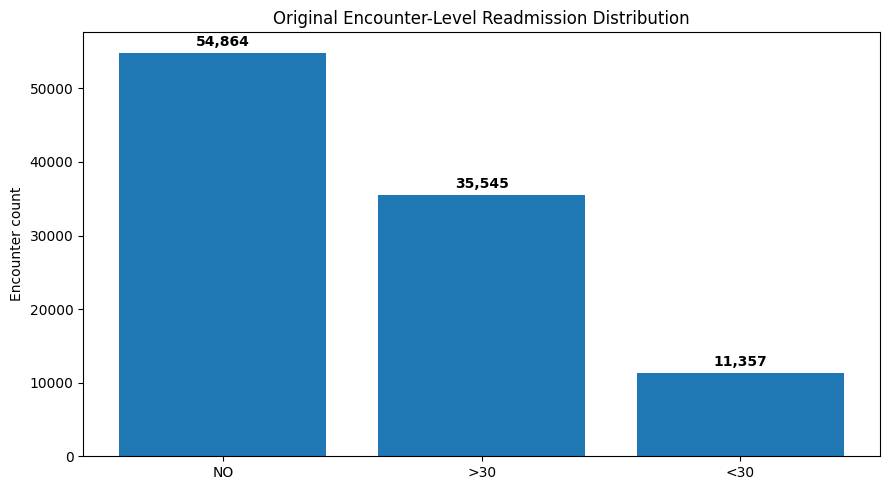

In [3]:
labels = ["NO", ">30", "<30"]
counts = [54864,35545,11357]
plt.figure(figsize=(9,5))
bars=plt.bar(labels,counts)
plt.ylabel("Encounter count")
plt.title("Original Encounter-Level Readmission Distribution")
for b,v in zip(bars,counts):
    plt.text(b.get_x()+b.get_width()/2,v+900,f"{v:,}",ha="center",fontweight="bold")
plt.tight_layout(); plt.show()

# 4. Why Patient-Level Representation?

The raw file contains multiple encounters for the same patient.

If encounters were treated as independent network nodes, the same person would be duplicated.

Therefore the project uses:

**Many encounters → one patient profile → one network node → one ABM agent**

The patient profile incorporates utilization, medication burden, diagnosis/procedure burden and demographic/context information while keeping the readmission outcome separate.

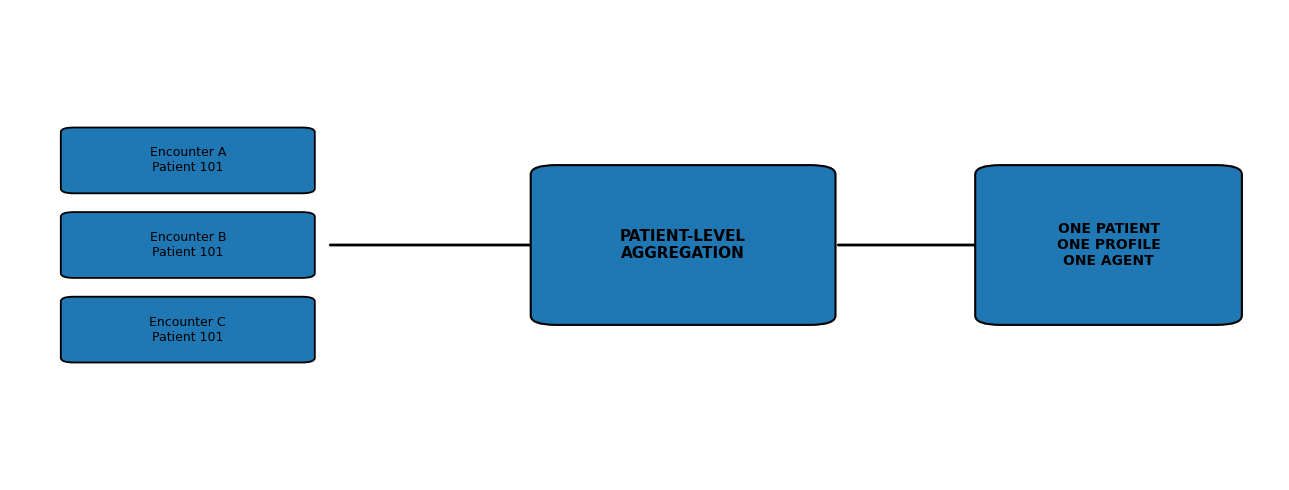

In [4]:
fig, ax = plt.subplots(figsize=(13,5)); ax.axis("off")
for y,t in zip([.68,.50,.32],["Encounter A\nPatient 101","Encounter B\nPatient 101","Encounter C\nPatient 101"]):
    ax.add_patch(FancyBboxPatch((.05,y-.06),.18,.12,boxstyle="round,pad=.01",linewidth=1.3))
    ax.text(.14,y,t,ha="center",va="center",fontsize=9)
ax.add_patch(FancyArrowPatch((.25,.5),(.43,.5),arrowstyle="->",mutation_scale=16,linewidth=2))
ax.add_patch(FancyBboxPatch((.43,.35),.20,.30,boxstyle="round,pad=.02",linewidth=1.5))
ax.text(.53,.50,"PATIENT-LEVEL\nAGGREGATION",ha="center",va="center",fontsize=11,fontweight="bold")
ax.add_patch(FancyArrowPatch((.65,.5),(.78,.5),arrowstyle="->",mutation_scale=16,linewidth=2))
ax.add_patch(FancyBboxPatch((.78,.35),.17,.30,boxstyle="round,pad=.02",linewidth=1.5))
ax.text(.865,.50,"ONE PATIENT\nONE PROFILE\nONE AGENT",ha="center",va="center",fontsize=10,fontweight="bold")
plt.xlim(0,1);plt.ylim(0,1);plt.tight_layout();plt.show()

# 5. Cleaning and Leakage Control

Notebook 02 explicitly handled:

- `?` missing markers;
- actual missing values;
- categorical standardization;
- identifiers;
- excluded/review-required variables.

### Leakage rules

- Readmission target is **not** a similarity feature.
- Patient ID is **not** a similarity feature.
- Preprocessing is fitted on **training only**.
- Test patients remain separate.
- Test outcomes are not used to tune intervention policies.
- The network is constructed from clinical representation, not outcome similarity.

A strict temporal split could not be verified because a reliable encounter timestamp was unavailable; CSV row order was not treated as chronology.

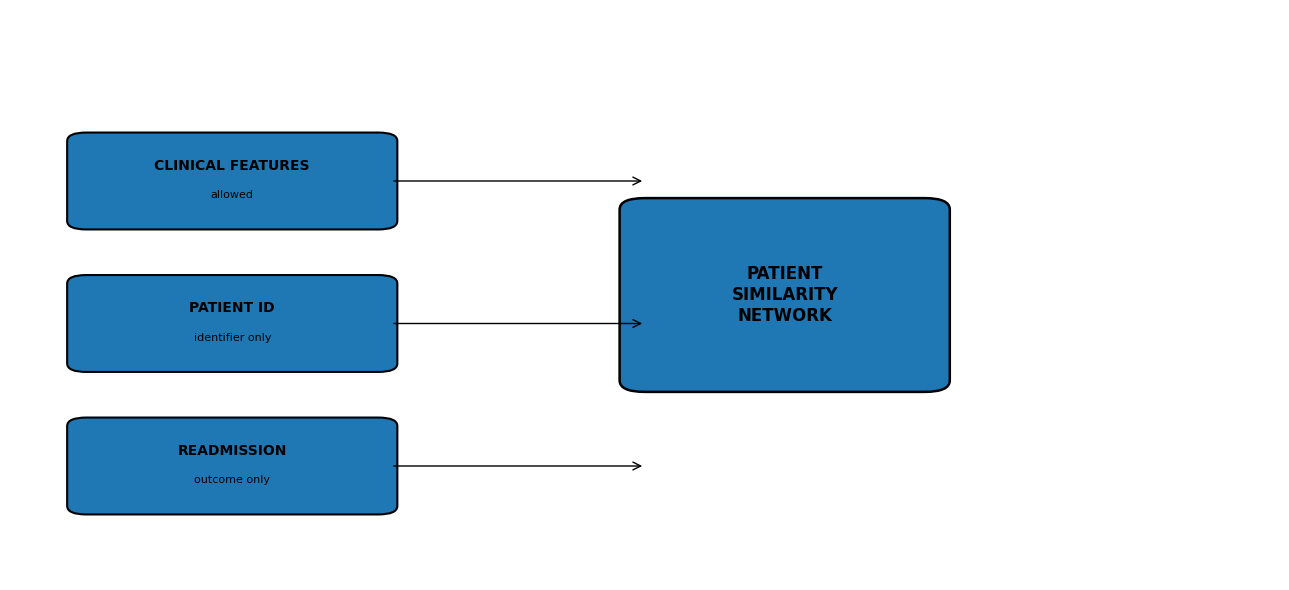

In [5]:
fig, ax = plt.subplots(figsize=(13,6)); ax.axis("off")
items=[(.06,.70,"CLINICAL FEATURES","allowed"),
       (.06,.45,"PATIENT ID","identifier only"),
       (.06,.20,"READMISSION","outcome only")]
for x,y,t,s in items:
    ax.add_patch(FancyBboxPatch((x,y-.07),.23,.14,boxstyle="round,pad=.015",linewidth=1.5))
    ax.text(x+.115,y+.02,t,ha="center",fontweight="bold",fontsize=10)
    ax.text(x+.115,y-.03,s,ha="center",fontsize=8)
ax.add_patch(FancyBboxPatch((.50,.35),.22,.30,boxstyle="round,pad=.02",linewidth=1.8))
ax.text(.61,.50,"PATIENT\nSIMILARITY\nNETWORK",ha="center",va="center",fontsize=12,fontweight="bold")
for y,text in [(.70,"used"),(.45,"excluded"),(.20,"excluded")]:
    ax.add_patch(FancyArrowPatch((.30,y),(.50,y),arrowstyle="->",mutation_scale=14))
plt.xlim(0,1);plt.ylim(0,1);plt.tight_layout();plt.show()

# 6. Patient Split

| Split | Patients |
|---|---:|
| Train | **50,062** |
| Validation | **10,728** |
| Test | **10,728** |
| Total | **71,518** |

There is **zero patient overlap** between the three sets.

The final test set is reserved for the frozen predictive model evaluation. Intervention experiments are performed on the held-out validation population.

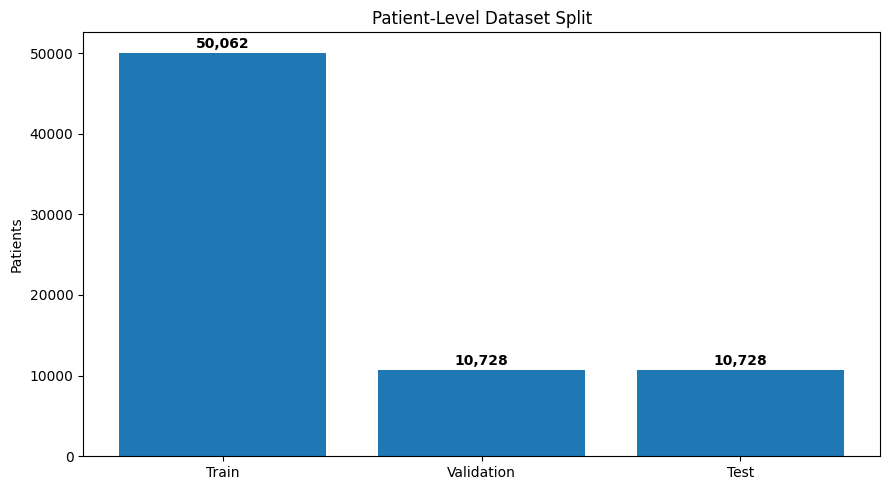

In [6]:
split_labels=["Train","Validation","Test"]; split_vals=[50062,10728,10728]
plt.figure(figsize=(9,5))
bars=plt.bar(split_labels,split_vals)
plt.ylabel("Patients");plt.title("Patient-Level Dataset Split")
for b,v in zip(bars,split_vals):
    plt.text(b.get_x()+b.get_width()/2,v+600,f"{v:,}",ha="center",fontweight="bold")
plt.tight_layout();plt.show()

# 7. Feature Engineering

The frozen similarity pipeline used:

- **38 candidate features**
- **32 numeric**
- **6 categorical**
- **57 transformed features**

The preprocessing was fitted on training data only.

### Similarity stability checks

- Mean neighbour Jaccard: **0.7007** comparing cosine and Euclidean neighbourhoods.
- Mean missingness-pattern neighbour similarity: **0.7668**.

These checks support a deliberate, auditable similarity representation rather than an arbitrary network.

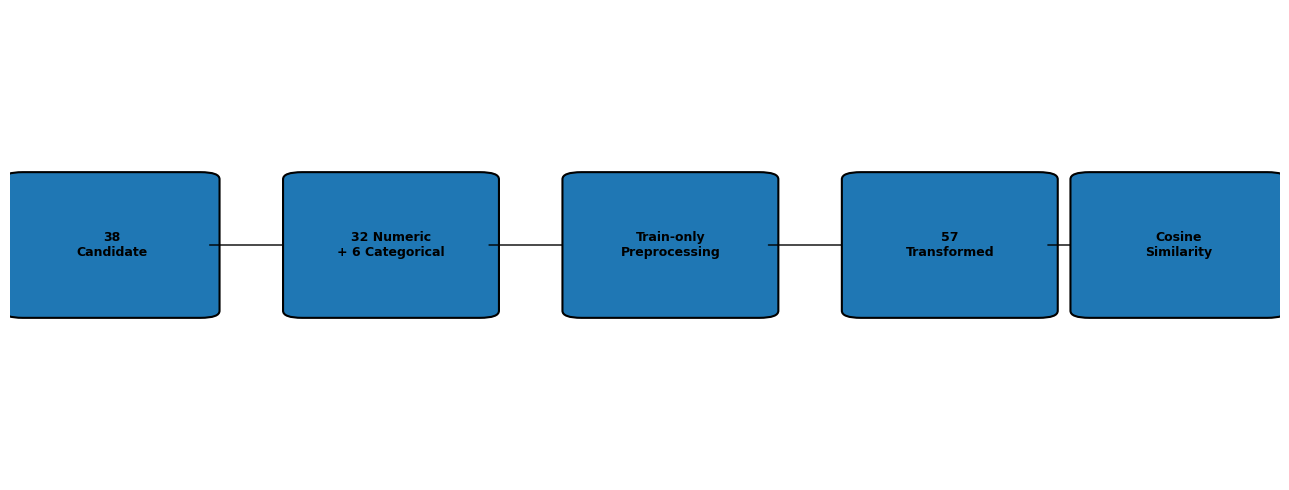

In [7]:
fig, ax = plt.subplots(figsize=(13,5)); ax.axis("off")
stages=[(.08,"38\nCandidate"),(.30,"32 Numeric\n+ 6 Categorical"),
        (.52,"Train-only\nPreprocessing"),(.74,"57\nTransformed"),
        (.92,"Cosine\nSimilarity")]
for i,(x,t) in enumerate(stages):
    ax.add_patch(FancyBboxPatch((x-.07,.36),.14,.28,boxstyle="round,pad=.015",linewidth=1.5))
    ax.text(x,.50,t,ha="center",va="center",fontsize=9,fontweight="bold")
    if i<len(stages)-1:
        ax.add_patch(FancyArrowPatch((x+.075,.50),(stages[i+1][0]-.075,.50),
                                     arrowstyle="->",mutation_scale=14))
plt.xlim(0,1);plt.ylim(0,1);plt.tight_layout();plt.show()

# 8. Patient Similarity Network

### Network definition

- **Node:** patient
- **Edge:** clinical similarity
- **Weight:** similarity strength
- **Rule:** mutual k-nearest neighbours
- **Primary k:** 10
- **Similarity:** cosine

### Primary network results

- **50,062 nodes**
- **434,595 edges**
- **Density:** 0.0003468
- **Mean degree:** 17.36
- **Median degree:** 18
- **Mean edge weight:** 0.9184
- **Median edge weight:** 0.9260
- **82 connected components**
- **Largest component:** 98.33% of training patients

The readmission outcome was not used to define the network.

,Metric,Value
0,Nodes,50062.0000
1,Edges,434595.0000
2,Mean degree,17.3623
3,Median degree,18.0000
4,Mean edge weight,0.9184
5,Median edge weight,0.9260
6,Connected components,82.0000


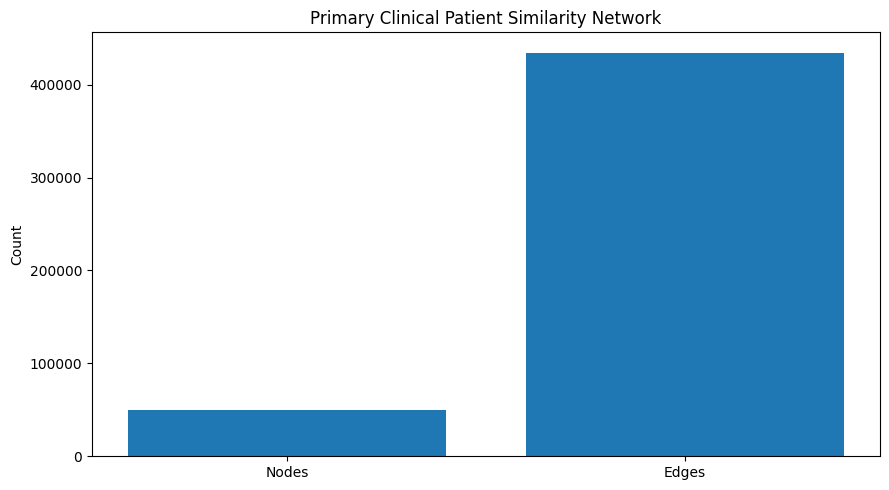

In [8]:
stats=pd.DataFrame({
"Metric":["Nodes","Edges","Mean degree","Median degree","Mean edge weight","Median edge weight","Connected components"],
"Value":[50062,434595,17.3623,18,0.9184,0.9260,82]})
display(stats)
plt.figure(figsize=(9,5));plt.bar(["Nodes","Edges"],[50062,434595])
plt.ylabel("Count");plt.title("Primary Clinical Patient Similarity Network")
plt.tight_layout();plt.show()

# 9. SNA: What does the network reveal?

Notebook 07 adds structural information to the patient representation.

### Primary SNA

- Approximate betweenness: **200 sampled sources**
- Landmark closeness: **100 sampled sources**
- Weighted eigenvector centrality
- Primary community method: **weighted Louvain**

### Community results

- **105 Louvain communities**
- **Largest community: 6,767 patients**
- **Weighted modularity: 0.8652**

Label propagation was used as a structural sensitivity analysis and produced **1,361 communities**.

These are communities of **clinically similar patients**, not social groups.

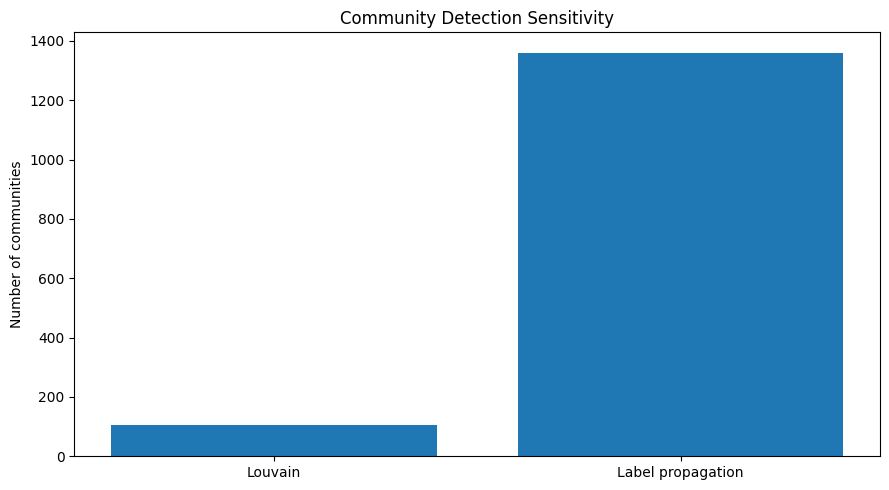

In [9]:
plt.figure(figsize=(9,5))
plt.bar(["Louvain","Label propagation"],[105,1361])
plt.ylabel("Number of communities")
plt.title("Community Detection Sensitivity")
plt.tight_layout();plt.show()

# 10. Conventional Readmission Model

Before using the ABM, a conventional predictive baseline was established.

### Validation performance

| Model | AUROC | AUPRC | Brier |
|---|---:|---:|---:|
| Random Forest | **0.8770** | **0.5933** | 0.1203 |
| Logistic Regression | 0.8708 | 0.5770 | **0.0751** |
| Prevalence baseline | 0.5000 | 0.1235 | 0.1083 |

The model was selected using **validation AUPRC**, so Random Forest was selected.

Threshold selected on validation: **0.70**.

,Model,AUROC,AUPRC,Brier
0,Random Forest,0.8770,0.5933,0.1203
1,Logistic Regression,0.8708,0.5770,0.0751
2,Prevalence baseline,0.5000,0.1235,0.1083


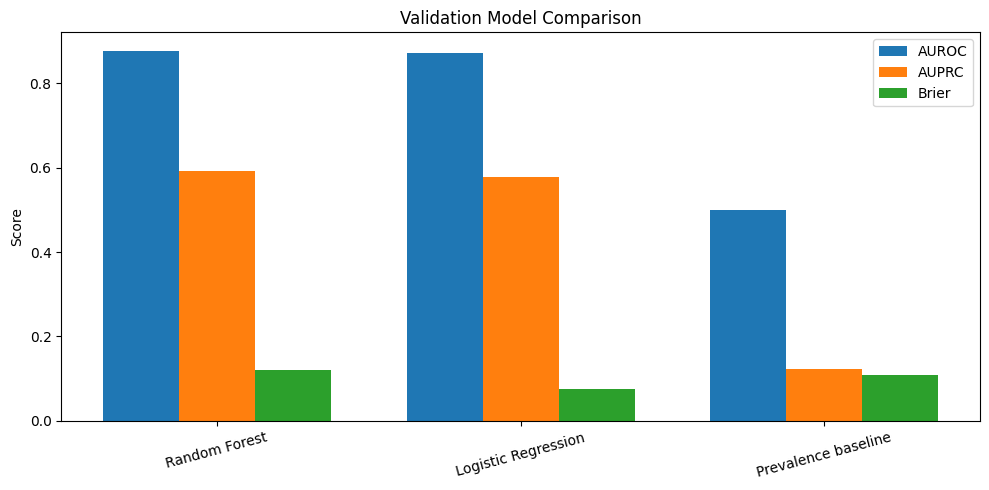

In [10]:
m=pd.DataFrame({"Model":["Random Forest","Logistic Regression","Prevalence baseline"],
"AUROC":[.8770,.8708,.5],"AUPRC":[.5933,.5770,.1235],"Brier":[.1203,.0751,.1083]})
display(m)
x=np.arange(3);w=.25
plt.figure(figsize=(10,5))
plt.bar(x-w,m.AUROC,w,label="AUROC");plt.bar(x,m.AUPRC,w,label="AUPRC");plt.bar(x+w,m.Brier,w,label="Brier")
plt.xticks(x,m.Model,rotation=15);plt.ylabel("Score");plt.title("Validation Model Comparison");plt.legend()
plt.tight_layout();plt.show()

# 11. Final Test Performance

After the model and threshold were frozen using validation data, the final test set produced:

- **AUROC = 0.8709**
- **AUPRC = 0.5883**
- **Brier = 0.1224**
- **Accuracy = 0.8702**
- **Precision = 0.4826**
- **Recall = 0.7019**
- **F1 = 0.5720**

### Confusion matrix

| | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0 | 8,406 | 997 |
| Actual 1 | 395 | 930 |

,Metric,Value
0,AUROC,0.8709
1,AUPRC,0.5883
2,Brier,0.1224
3,Accuracy,0.8702
4,Precision,0.4826
5,Recall,0.7019
6,F1,0.5720


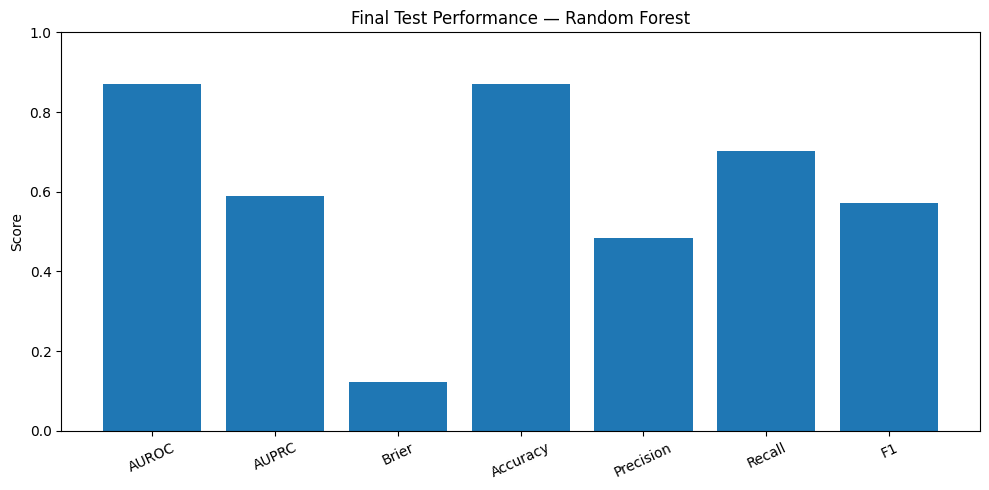

In [11]:
metrics=pd.DataFrame({"Metric":["AUROC","AUPRC","Brier","Accuracy","Precision","Recall","F1"],
"Value":[.8709,.5883,.1224,.8702,.4826,.7019,.5720]})
display(metrics)
plt.figure(figsize=(10,5));plt.bar(metrics.Metric,metrics.Value);plt.ylim(0,1)
plt.ylabel("Score");plt.title("Final Test Performance — Random Forest");plt.xticks(rotation=25)
plt.tight_layout();plt.show()

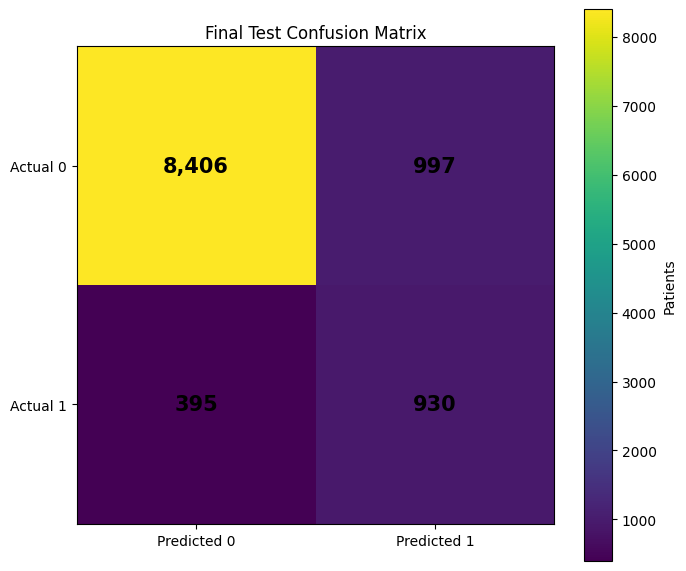

In [12]:
cm=np.array([[8406,997],[395,930]])
fig,ax=plt.subplots(figsize=(7,6)); im=ax.imshow(cm)
ax.set_xticks([0,1]);ax.set_yticks([0,1])
ax.set_xticklabels(["Predicted 0","Predicted 1"]);ax.set_yticklabels(["Actual 0","Actual 1"])
for i in range(2):
    for j in range(2):
        ax.text(j,i,f"{cm[i,j]:,}",ha="center",va="center",fontsize=15,fontweight="bold")
ax.set_title("Final Test Confusion Matrix");plt.colorbar(im,ax=ax,label="Patients")
plt.tight_layout();plt.show()

# 12. Why ABM after Prediction?

The predictive model answers:

> **Who has higher predicted readmission risk?**

The ABM lets us ask a different question:

> **What happens when a fixed intervention resource is allocated using different targeting policies?**

### Agent state

The ABM represents patients using:

- clinical state;
- utilization state;
- baseline risk;
- network state;
- intervention state;
- simulated outcome state.

The first ABM deliberately uses a probabilistic readmission transition rather than inventing unsupported physiological dynamics.

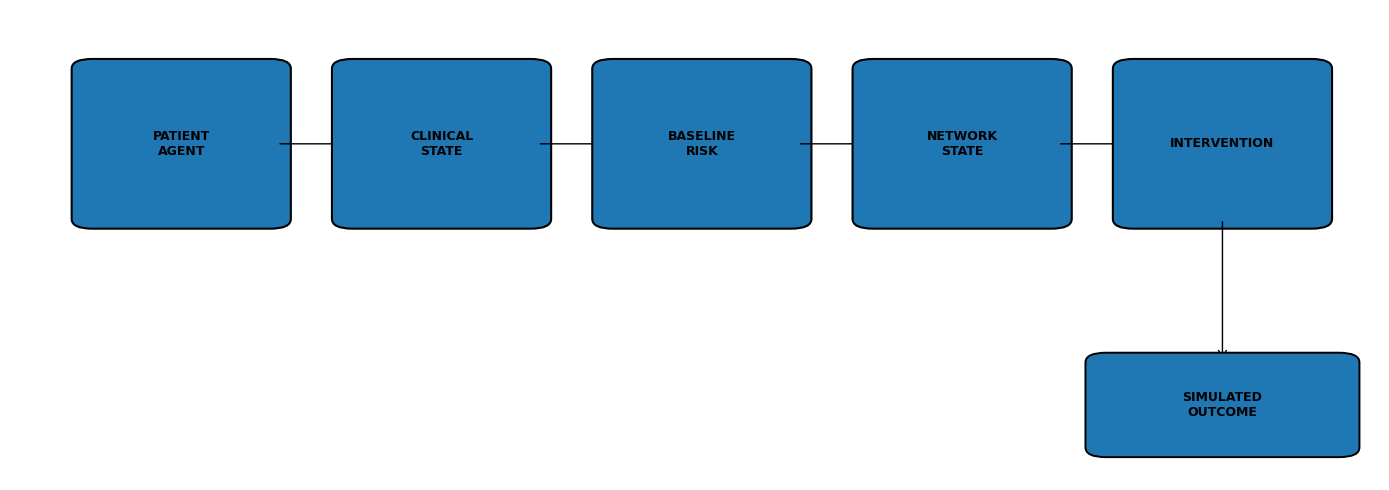

In [13]:
fig,ax=plt.subplots(figsize=(14,5));ax.axis("off")
items=[(.06,"PATIENT\nAGENT"),(.25,"CLINICAL\nSTATE"),(.44,"BASELINE\nRISK"),
       (.63,"NETWORK\nSTATE"),(.82,"INTERVENTION"),(.82,"OUTCOME")]
for i,(x,t) in enumerate(items[:5]):
    ax.add_patch(FancyBboxPatch((x,.40),.13,.23,boxstyle="round,pad=.015",linewidth=1.5))
    ax.text(x+.065,.515,t,ha="center",va="center",fontsize=9,fontweight="bold")
    if i<4: ax.add_patch(FancyArrowPatch((x+.135,.515),(items[i+1][0]-.005,.515),arrowstyle="->",mutation_scale=13))
ax.add_patch(FancyArrowPatch((.885,.40),(.885,.18),arrowstyle="->",mutation_scale=14))
ax.add_patch(FancyBboxPatch((.80,.05),.17,.13,boxstyle="round,pad=.015",linewidth=1.4))
ax.text(.885,.115,"SIMULATED\nOUTCOME",ha="center",va="center",fontsize=9,fontweight="bold")
plt.xlim(0,1);plt.ylim(0,0.72);plt.tight_layout();plt.show()

# 13. ABM Validation

Notebook 10 evaluates the calibrated no-intervention ABM on the **10,728-patient validation population**.

The observed validation outcome is used for model validation, not for:

- constructing the similarity network;
- assigning network structure from the training graph;
- selecting intervention targets.

The validation simulation contains outcome states such as `stable` and `readmitted`.

The purpose is to establish that the simulation has reasonable aggregate behaviour before intervention experiments are interpreted.

,Observed validation patients
stable,9356
readmitted,1372


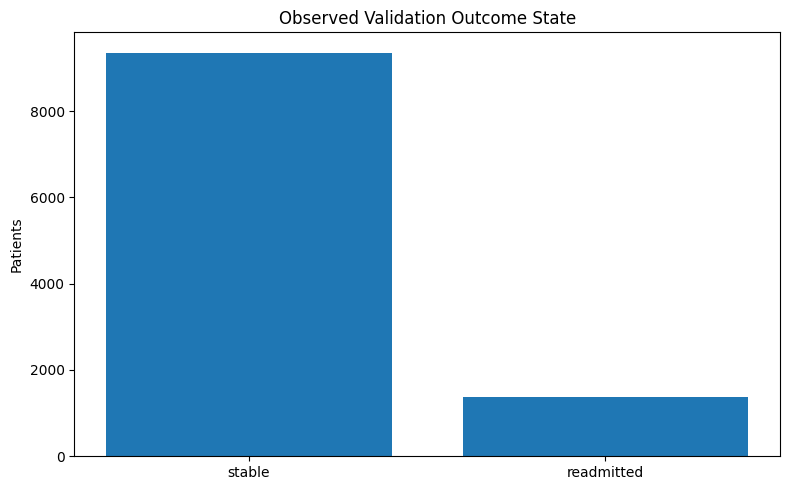

Observed validation readmission rate: 0.1279


In [14]:
obs=pd.Series({"stable":9356,"readmitted":1372})
display(obs.to_frame("Observed validation patients"))
plt.figure(figsize=(8,5));plt.bar(obs.index,obs.values)
plt.ylabel("Patients");plt.title("Observed Validation Outcome State")
plt.tight_layout();plt.show()
print("Observed validation readmission rate:",round(1372/10728,4))

# 14. Intervention Experiment

Four policies are compared on the **same validation population**:

1. **No intervention**
2. **Random**
3. **Risk-based**
4. **Network-informed**

### Equal-resource design

Validation population:

**10,728 patients**

Intervention budget:

**10% = 1,073 targeted patients**

The same population, intervention budget and replication design are used across competing targeted policies.

This is the key fairness condition in the intervention experiment.

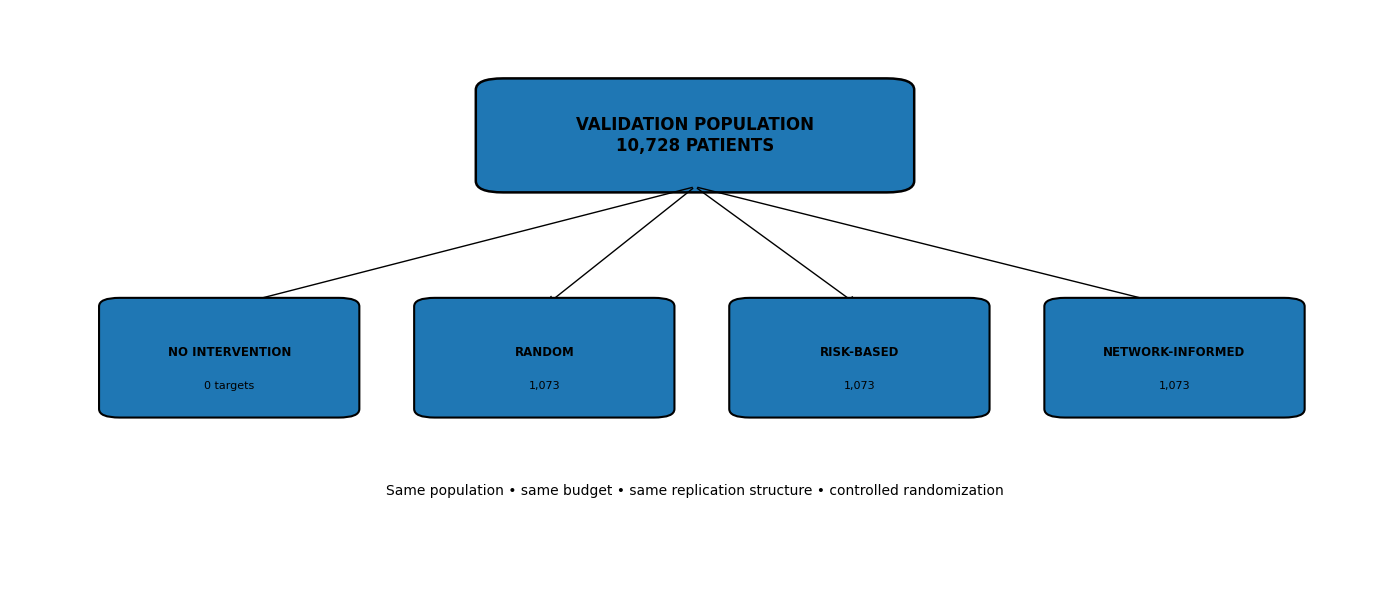

In [15]:
fig,ax=plt.subplots(figsize=(14,6));ax.axis("off")
ax.add_patch(FancyBboxPatch((.36,.70),.28,.16,boxstyle="round,pad=.02",linewidth=1.8))
ax.text(.50,.78,"VALIDATION POPULATION\n10,728 PATIENTS",ha="center",va="center",fontsize=12,fontweight="bold")
pol=[(.08,"NO INTERVENTION","0 targets"),(.31,"RANDOM","1,073"),(.54,"RISK-BASED","1,073"),(.77,"NETWORK-INFORMED","1,073")]
for x,t,s in pol:
    ax.add_patch(FancyArrowPatch((.50,.69),(x+.08,.48),arrowstyle="->",mutation_scale=13))
    ax.add_patch(FancyBboxPatch((x,.30),.16,.18,boxstyle="round,pad=.015",linewidth=1.5))
    ax.text(x+.08,.40,t,ha="center",va="center",fontsize=8.5,fontweight="bold")
    ax.text(x+.08,.34,s,ha="center",va="center",fontsize=8)
ax.text(.50,.15,"Same population • same budget • same replication structure • controlled randomization",
        ha="center",fontsize=10)
plt.xlim(0,1);plt.ylim(0,1);plt.tight_layout();plt.show()

# 15. Intervention Results — Loaded from Notebook 11

The next cells inspect the actual saved Notebook 11 outputs.

The presentation deliberately does **not** hard-code the intervention outcome. It reads the project's saved CSV files and displays the actual table/figure.

In [16]:
files=sorted(RESULTS.glob("*"))
intervention=[p for p in files if any(k in p.name.lower() for k in ["11_intervention","11_policy","11_paired","11_target"])]
print("Notebook 11 files:")
for p in intervention: print(" -",p.name)

def load_candidates(keys):
    for p in intervention:
        if p.suffix.lower()==".csv" and all(k in p.name.lower() for k in keys):
            return pd.read_csv(p),p
    return None,None

policy_df,policy_path=load_candidates(["policy"])
if policy_df is not None:
    print("Policy summary:",policy_path.name)
    display(policy_df)
else:
    print("A policy summary CSV was not found. Use the saved Notebook 11 figures shown later.")

Notebook 11 files:
 - 11_intervention_config.json
 - 11_intervention_policy_summary.csv
 - 11_intervention_replication_results.csv
 - 11_paired_policy_comparisons.csv
 - 11_target_selection_audit.csv
Policy summary: 11_intervention_policy_summary.csv


,policy,replications,patients_per_replication,intervention_count,mean_readmission_rate,sd_readmission_rate,ci95_low,ci95_high,mean_prevented_vs_no_intervention,mean_absolute_reduction,mean_relative_reduction,mean_intervention_efficiency
0,no_intervention,100.0,10728.0,0.0,0.123241,0.002561,0.122739,0.123743,0.00,0.000000,0.000000,NaN
1,random,100.0,10728.0,1073.0,0.120807,0.002580,0.120302,0.121313,26.11,0.002434,0.019753,0.024334
2,risk_based,100.0,10728.0,1073.0,0.110539,0.002549,0.110039,0.111038,136.27,0.012702,0.103080,0.126999
3,network_informed,100.0,10728.0,1073.0,0.112145,0.002574,0.111640,0.112649,119.04,0.011096,0.090053,0.110941


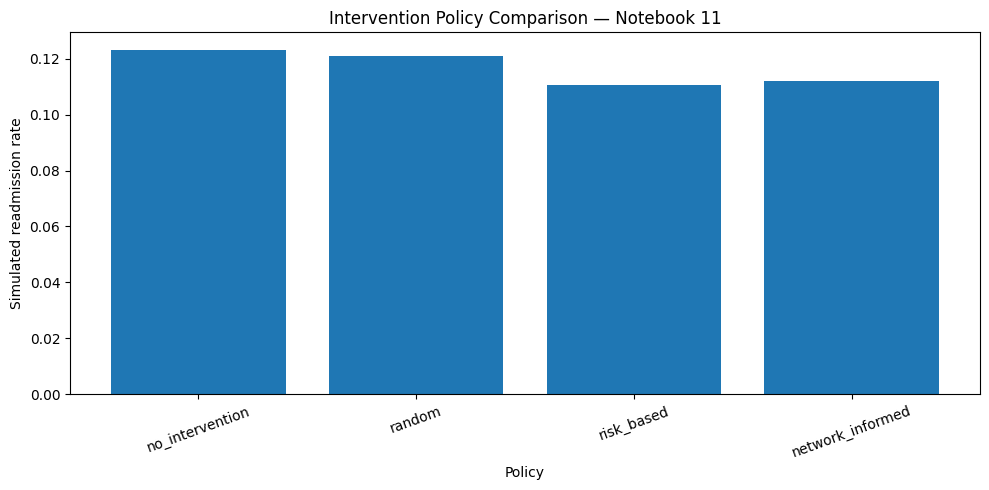

In [17]:
# Flexible policy chart
if policy_df is not None:
    pcol=next((c for c in policy_df.columns if c.lower() in ["policy","intervention_policy"]),None)
    rcol=next((c for c in policy_df.columns if "readmission" in c.lower() and "rate" in c.lower()),None)
    if pcol and rcol:
        d=policy_df[[pcol,rcol]].dropna()
        plt.figure(figsize=(10,5));plt.bar(d[pcol].astype(str),pd.to_numeric(d[rcol],errors="coerce"))
        plt.ylabel("Simulated readmission rate");plt.xlabel("Policy")
        plt.title("Intervention Policy Comparison — Notebook 11")
        plt.xticks(rotation=20);plt.tight_layout();plt.show()
    else:
        print("Recognized policy/readmission-rate columns were not found.")

# 16. Prevented Readmissions and Intervention Efficiency

The primary intervention quantities to report are:

- simulated readmission rate;
- absolute reduction versus no intervention;
- relative reduction;
- prevented simulated readmissions;
- intervention efficiency;
- comparison with random targeting;
- uncertainty across replications.

The interpretation is:

> **How do the policies behave under the same resource constraint and the assumptions of the ABM?**

It is not a claim of causal clinical treatment effectiveness.

Saved intervention figures: 3
11_intervention_policy_comparison.png


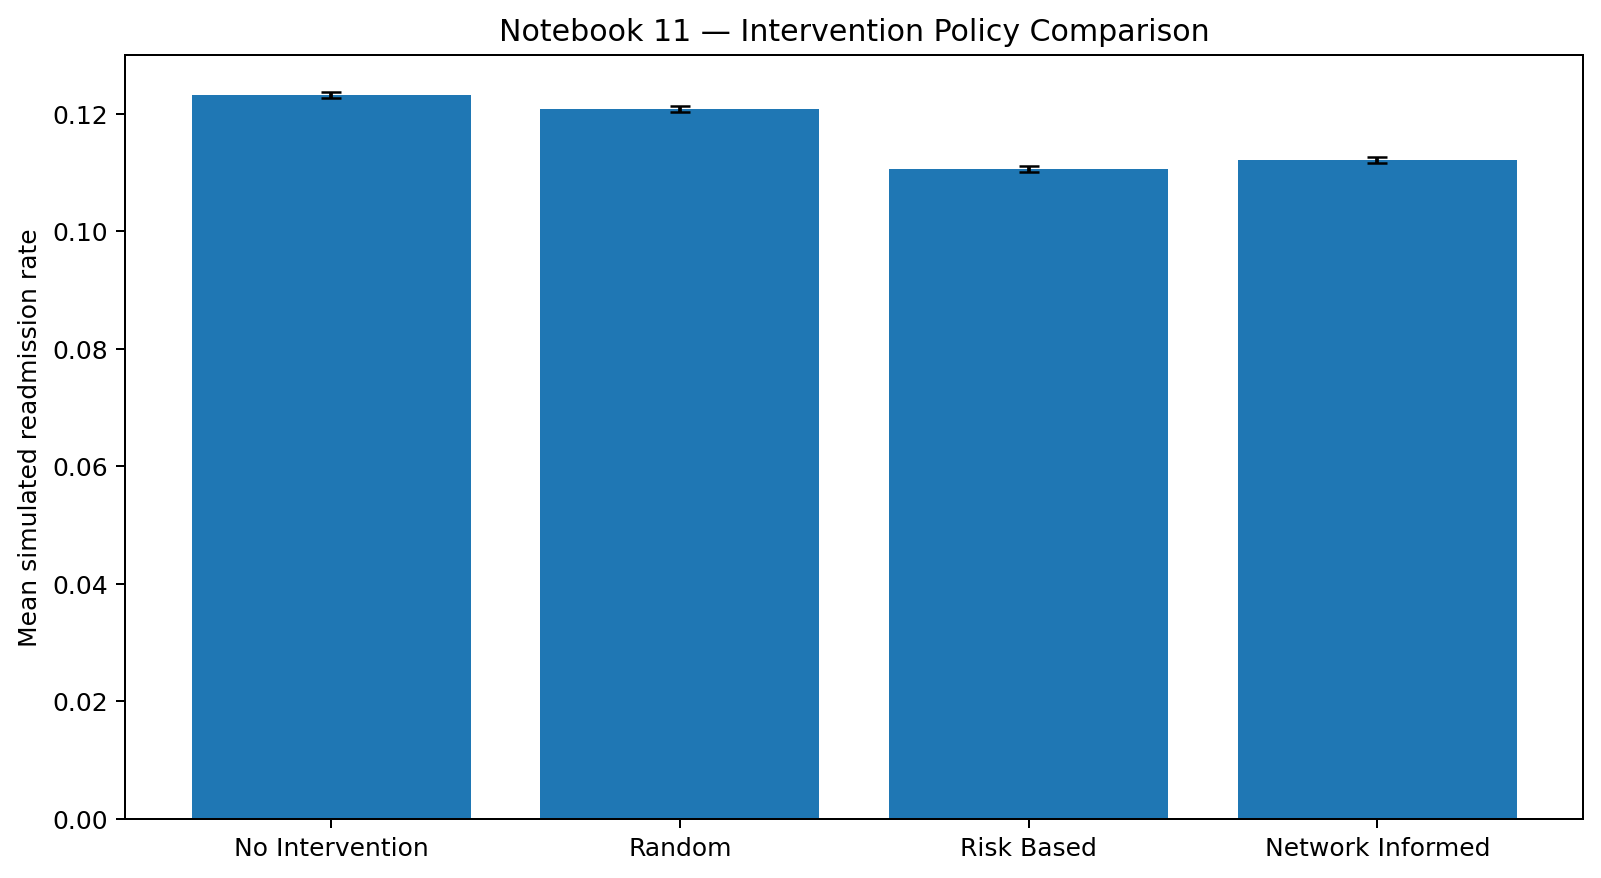

11_prevented_readmissions.png


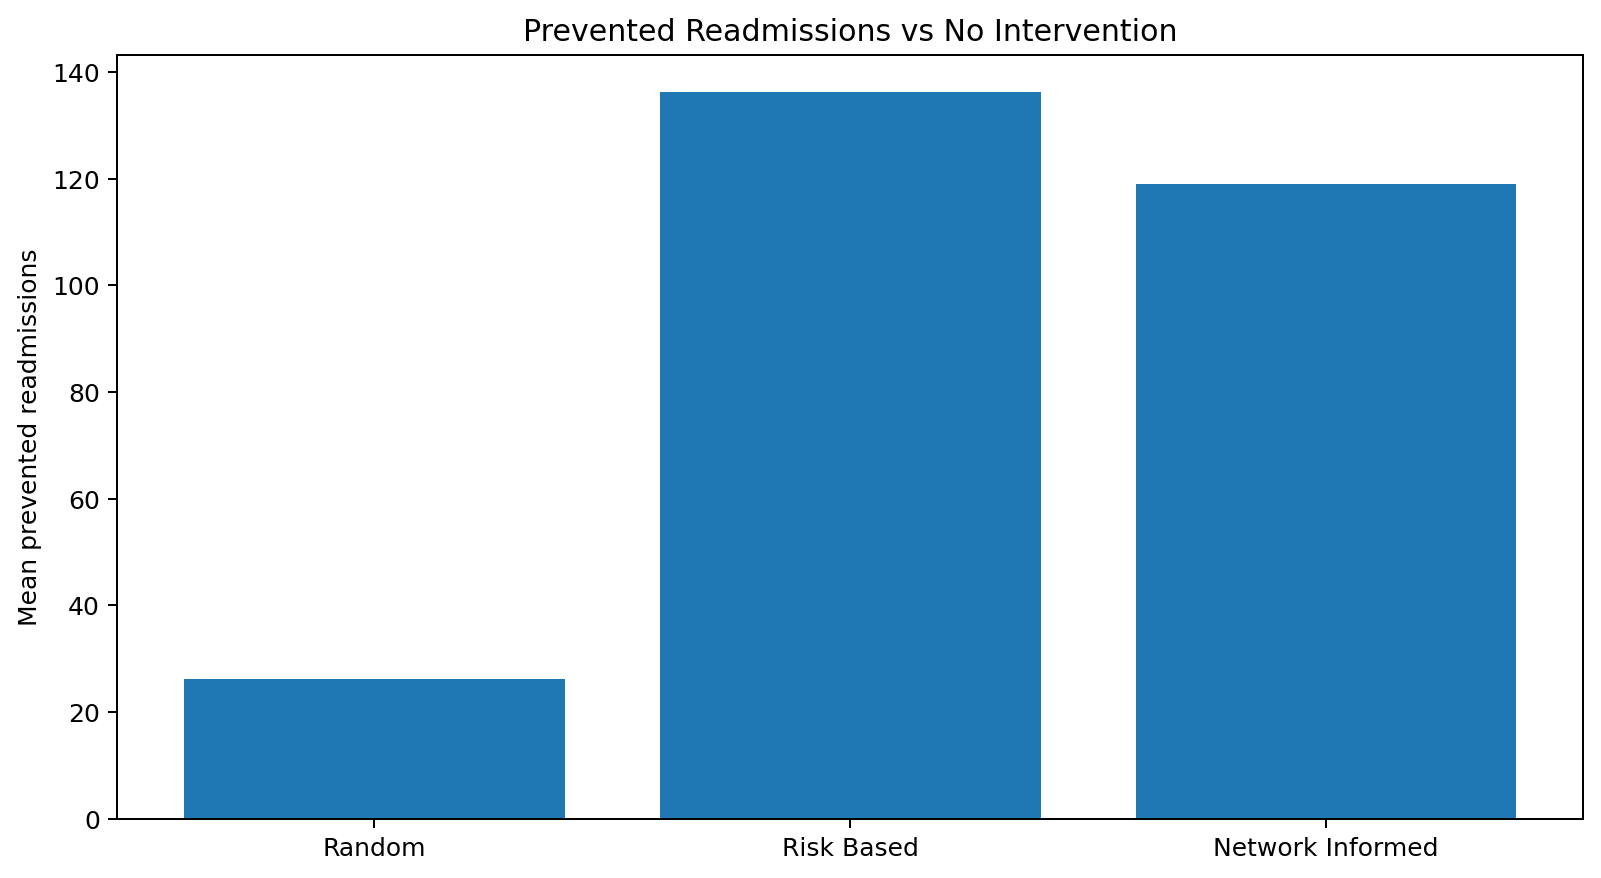

12_targeting_policy_ablation.png


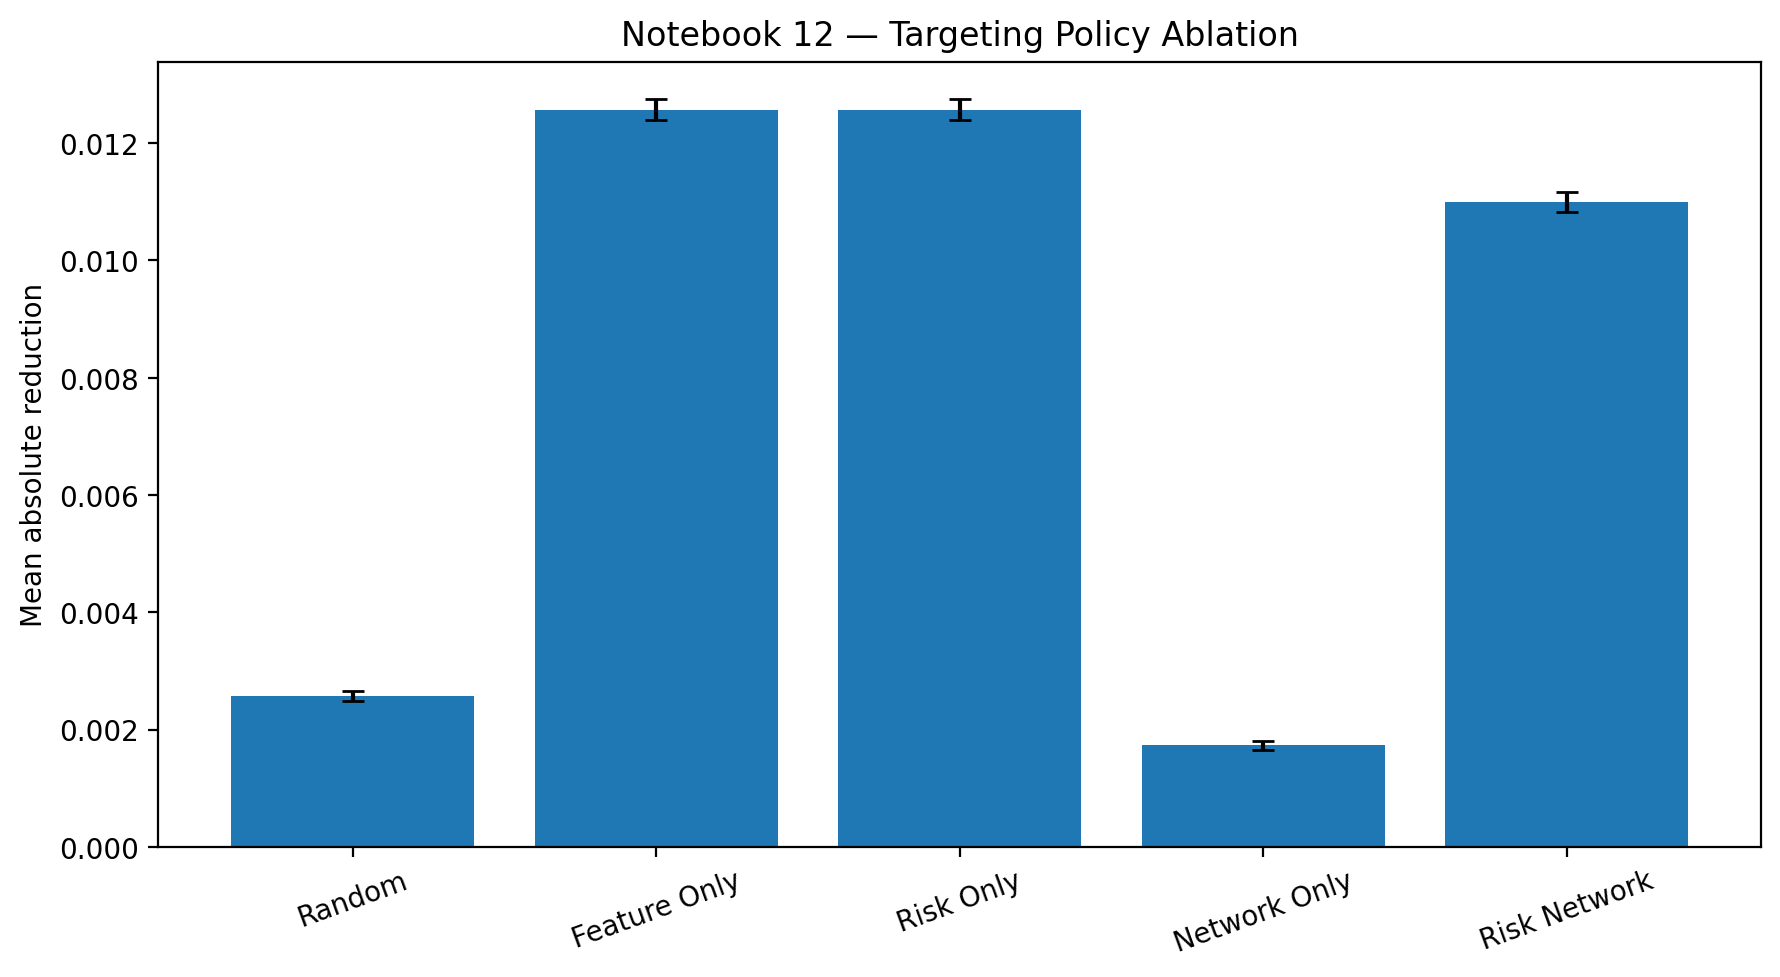

In [18]:
# Show saved intervention figures
figs=[p for p in sorted(FIGURES.glob("*.png"))
      if any(k in p.name.lower() for k in ["intervention","policy","prevented"])]
print("Saved intervention figures:",len(figs))
for p in figs:
    print(p.name)
    display(Image(filename=str(p)))

# 17. Robustness and Ablation

Notebook 12 tests whether the intervention evidence is sensitive to:

- network `k` / construction;
- intervention budget;
- intervention effectiveness;
- stochastic seeds;
- centrality choice;
- feature-only ablation;
- network-only ablation;
- risk-only ablation;
- risk + network combinations.

### Why?

A result from one simulation configuration should not be presented as universally stable.

Robustness tells us how the result changes when reasonable assumptions are changed.

In [19]:
rob_files=[p for p in sorted(RESULTS.glob("*"))
           if any(k in p.name.lower() for k in ["12_robust","12_effect","12_ablation","12_network","12_seed","12_budget","12_stochastic"])]
print("Notebook 12 outputs:")
for p in rob_files: print(" -",p.name)

Notebook 12 outputs:
 - 12_ablation_results.csv
 - 12_ablation_summary.csv
 - 12_effect_sizes.csv
 - 12_network_sensitivity.csv
 - 12_network_target_stability.csv
 - 12_robustness_config.json
 - 12_robustness_summary.csv
 - 12_seed_robustness.csv
 - 12_seed_summary.csv


In [20]:
for p in rob_files:
    if p.suffix.lower()==".csv":
        try:
            d=pd.read_csv(p)
            print("\n",p.name,"shape =",d.shape)
            display(d.head(15))
        except Exception as e:
            print("Could not read",p.name,e)


 12_ablation_results.csv shape = (500, 5)


,policy,replication,readmission_rate,absolute_reduction,intervention_count
0,random,0,0.120805,0.002424,1073
1,feature_only,0,0.111204,0.012025,1073
2,risk_only,0,0.111204,0.012025,1073
3,network_only,0,0.122017,0.001212,1073
4,risk_network,0,0.112696,0.010533,1073
5,random,1,0.121551,0.002890,1073
6,feature_only,1,0.109526,0.014914,1073
7,risk_only,1,0.109526,0.014914,1073
8,network_only,1,0.122856,0.001585,1073
9,risk_network,1,0.111857,0.012584,1073



 12_ablation_summary.csv shape = (5, 7)


,policy,mean_readmission_rate,sd_readmission_rate,mean_absolute_reduction,ci95_low,ci95_high,mean_intervention_count
0,feature_only,0.111180,0.002454,0.012574,0.012396,0.012751,1073.0
1,network_only,0.122018,0.002354,0.001736,0.001660,0.001811,1073.0
2,random,0.121182,0.002418,0.002572,0.002482,0.002662,1073.0
3,risk_network,0.112757,0.002535,0.010996,0.010825,0.011168,1073.0
4,risk_only,0.111180,0.002454,0.012574,0.012396,0.012751,1073.0



 12_effect_sizes.csv shape = (64, 7)


...

,policy,budget_fraction,intervention_effect,mean_readmission_rate,sd_readmission_rate,mean_absolute_reduction,mean_relative_reduction,mean_prevented,sd_prevented,mean_efficiency,n_replications,ci95_low,ci95_high
0,network_only,0.05,0.1,0.122644,0.002492,0.000346,0.002811,3.71,1.776928,0.006922,100,-0.000143,0.000834
1,network_only,0.05,0.2,0.122261,0.002495,0.000728,0.005919,7.81,2.529403,0.014571,100,0.000239,0.001217
2,network_only,0.05,0.3,0.121934,0.002520,0.001055,0.008584,11.32,3.064558,0.021119,100,0.000561,0.001549
3,network_only,0.05,0.5,0.121198,0.002558,0.001792,0.014578,19.22,3.788819,0.035858,100,0.001290,0.002293
4,network_only,0.10,0.1,0.122095,0.002533,0.000894,0.007275,9.59,2.885334,0.008938,100,0.000397,0.001390
5,network_only,0.10,0.2,0.121143,0.002597,0.001847,0.015031,19.81,4.629058,0.018462,100,0.001338,0.002356
6,network_only,0.10,0.3,0.120290,0.002612,0.002699,0.021968,28.96,5.604688,0.026990,100,0.002188,0.003211
7,network_only,0.10,0.5,0.118471,0.002615,0.004518,0.036759,48.47,6.320489,0.045172,100,0.004005,0.005031
8,network_only,0.20,0.1,0.121027,0.002580,0.001962,0.015969,21.05,4.269637,0.009809,100,0.001456,0.002468
9,network_only,0.20,0.2,0.119045,0.002623,0.003944,0.032090,42.31,6.335239,0.019716,100,0.003430,0.004458



 12_seed_robustness.csv shape = (600, 6)


,seed,replication,policy,readmission_rate,absolute_reduction,intervention_count
0,42,0,random,0.125652,0.002237,1073
1,42,0,risk_only,0.115772,0.012118,1073
2,42,0,network_only,0.125932,0.001957,1073
3,42,0,risk_network,0.117356,0.010533,1073
4,42,1,random,0.120246,0.002330,1073
5,42,1,risk_only,0.110645,0.011931,1073
6,42,1,network_only,0.120339,0.002237,1073
7,42,1,risk_network,0.111857,0.010720,1073
8,42,2,random,0.118289,0.002330,1073
9,42,2,risk_only,0.109993,0.010626,1073



 12_seed_summary.csv shape = (4, 6)


,policy,mean_reduction,sd_reduction,min_reduction,max_reduction,n
0,network_only,0.001771,0.000390,0.000839,0.002517,150
1,random,0.002425,0.000425,0.001305,0.003449,150
2,risk_network,0.010751,0.000808,0.008389,0.012957,150
3,risk_only,0.012387,0.000883,0.010160,0.014728,150


# 18. Network-k Sensitivity

The network sensitivity output must be described using the metrics it actually contains.

For example, if the table contains:

- nodes;
- edges;
- density;
- mean weighted degree;
- median weighted degree;
- isolated nodes;

then it supports a conclusion about **network structural sensitivity**.

It should not be called “target-set Jaccard stability” unless an actual Jaccard/overlap statistic is present.

,metric,k,nodes,edges,density,mean_weighted_degree,median_weighted_degree,isolated_nodes
0,cosine,5,10728,14392,0.000250,2.480298,2.653894,953
1,cosine,10,10728,30245,0.000526,5.129076,5.237948,248
2,cosine,20,10728,62621,0.001088,10.416738,10.370403,34
3,cosine,30,10728,95851,0.001666,15.742751,15.727120,7
4,euclidean,5,10728,13850,0.000241,0.940770,0.819610,1055
5,euclidean,10,10728,28795,0.000500,1.826193,1.650471,300
6,euclidean,20,10728,58077,0.001009,3.456475,3.135922,73
7,euclidean,30,10728,87448,0.001520,5.022413,4.570724,23


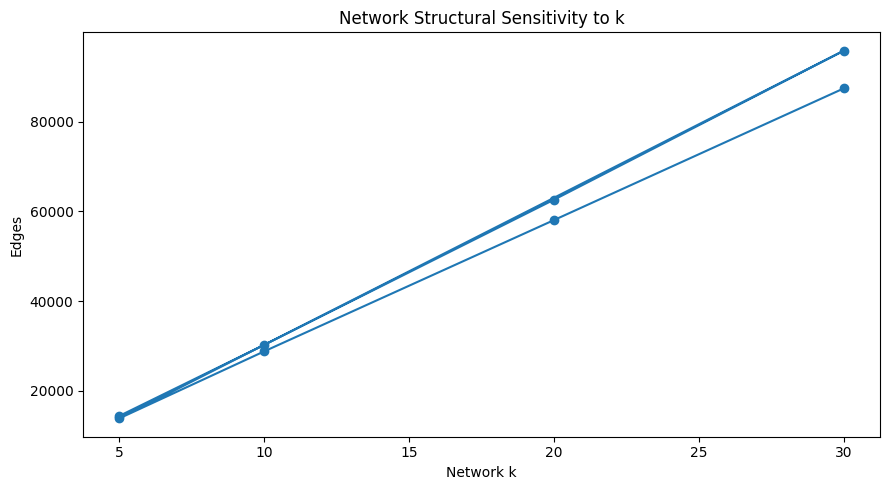

In [21]:
ns=None
for p in rob_files:
    if "network_sensitivity" in p.name.lower() and p.suffix.lower()==".csv":
        ns=pd.read_csv(p);break

if ns is None:
    print("Network sensitivity table not found.")
else:
    display(ns)
    if "k" in ns.columns and "edges" in ns.columns:
        plt.figure(figsize=(9,5));plt.plot(ns["k"],ns["edges"],marker="o")
        plt.xlabel("Network k");plt.ylabel("Edges")
        plt.title("Network Structural Sensitivity to k")
        plt.tight_layout();plt.show()

# 19. Stochasticity / Uncertainty

Because the ABM is stochastic, repeated runs can produce different outcomes.

Therefore the project uses:

- fixed seeds for reproducibility;
- repeated replications;
- common randomization controls where appropriate;
- uncertainty summaries.

The correct presentation is to show the distribution or interval across replications, not only one random simulation run.

Using 11_intervention_replication_results.csv


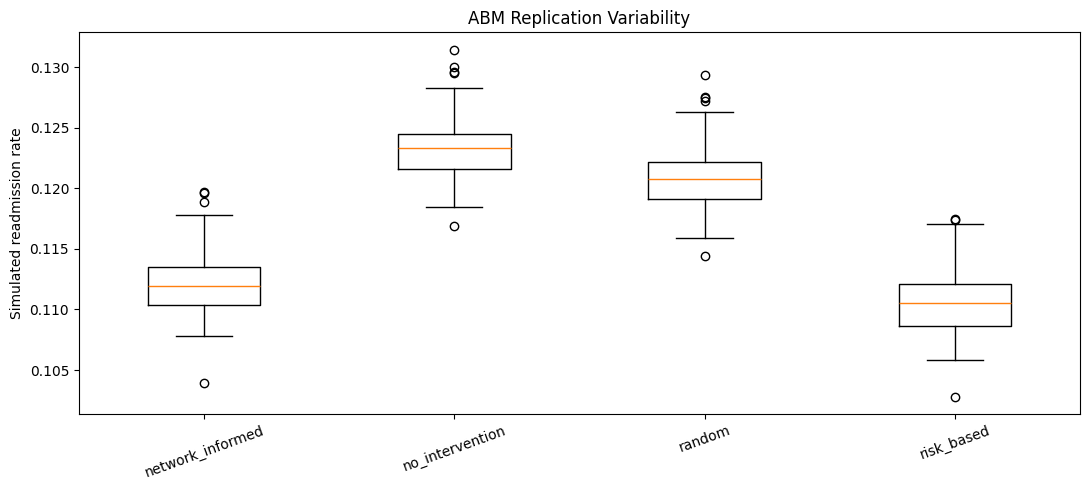

In [22]:
rep=None
for p in intervention:
    if "replication" in p.name.lower() and p.suffix.lower()==".csv":
        try: rep=pd.read_csv(p); print("Using",p.name); break
        except: pass

if rep is not None:
    pcol=next((c for c in rep.columns if c.lower() in ["policy","intervention_policy"]),None)
    rcol=next((c for c in rep.columns if "readmission" in c.lower() and "rate" in c.lower()),None)
    if pcol and rcol:
        groups=[g[rcol].dropna().values for _,g in rep.groupby(pcol)]
        labs=[str(k) for k,_ in rep.groupby(pcol)]
        plt.figure(figsize=(11,5));plt.boxplot(groups,labels=labs)
        plt.ylabel("Simulated readmission rate");plt.title("ABM Replication Variability")
        plt.xticks(rotation=20);plt.tight_layout();plt.show()
    else:
        print("No recognized replication columns.")
else:
    print("Replication table not found.")

# 20. Complete Evidence Table

| Stage | Main evidence |
|---|---|
| Dataset | 101,766 encounters; 71,518 patients |
| Data quality | 0 duplicate rows; 0 duplicate encounter IDs |
| Split | 50,062 / 10,728 / 10,728 |
| Features | 38 candidate → 57 transformed |
| Similarity | Cosine; neighbour Jaccard ≈ 0.701 |
| Network | 50,062 nodes; 434,595 edges; k=10 |
| SNA | 105 Louvain communities; modularity 0.8652 |
| Baseline | Random Forest validation AUPRC 0.5933 |
| Test | AUROC 0.8709; AUPRC 0.5883; F1 0.5720 |
| ABM | Probabilistic readmission transition |
| Validation | 10,728 held-out validation patients |
| Intervention | 4 policies |
| Budget | 10% = 1,073 targeted patients |
| Robustness | Network, budget, effectiveness, stochasticity, ablation |

# 21. What is the contribution?

### Prediction

The model estimates individual readmission risk.

### Network

The clinical similarity graph describes how patients are structurally related.

### SNA

Centrality and communities add population structure.

### ABM

Agents allow controlled intervention experiments.

### Robustness

Sensitivity and ablation test whether the simulated findings depend on modelling choices.

So the project is not only:

**“Can we predict readmission?”**

It is:

**“Can we connect patient risk and clinical similarity structure to a controlled intervention simulation?”**

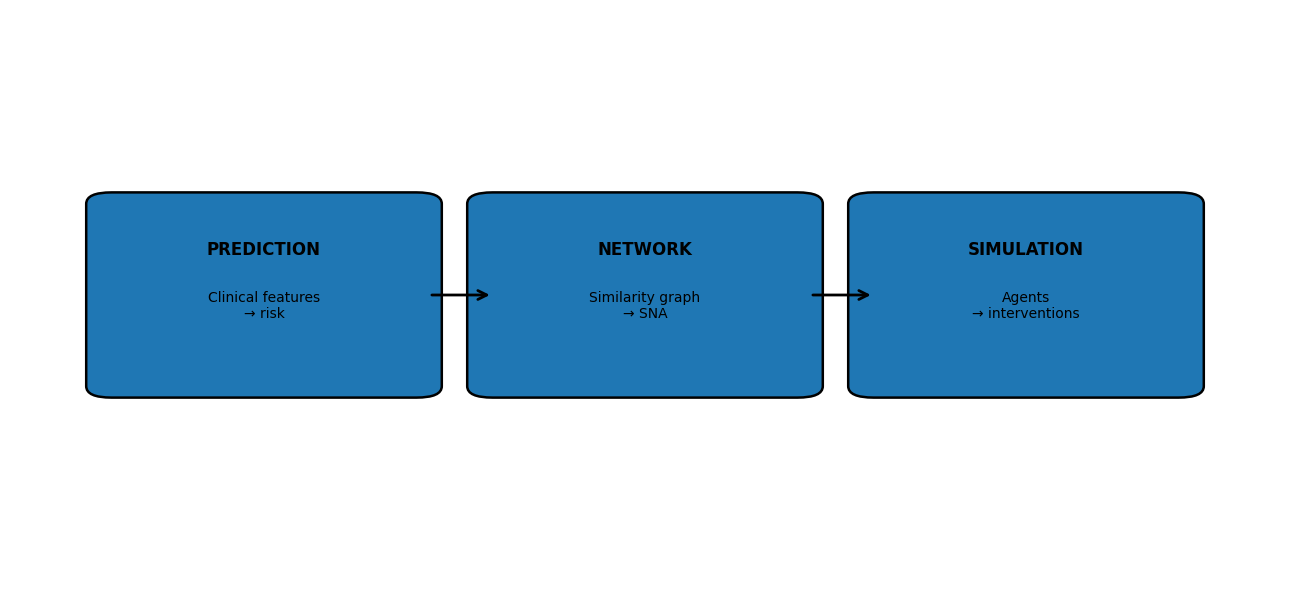

In [23]:
fig,ax=plt.subplots(figsize=(13,6));ax.axis("off")
layers=[(.08,"PREDICTION","Clinical features\n→ risk"),
        (.38,"NETWORK","Similarity graph\n→ SNA"),
        (.68,"SIMULATION","Agents\n→ interventions")]
for x,t,b in layers:
    ax.add_patch(FancyBboxPatch((x,.34),.24,.32,boxstyle="round,pad=.02",linewidth=1.8))
    ax.text(x+.12,.57,t,ha="center",fontsize=12,fontweight="bold")
    ax.text(x+.12,.46,b,ha="center",fontsize=10)
ax.add_patch(FancyArrowPatch((.33,.50),(.38,.50),arrowstyle="->",mutation_scale=16,linewidth=2))
ax.add_patch(FancyArrowPatch((.63,.50),(.68,.50),arrowstyle="->",mutation_scale=16,linewidth=2))
plt.xlim(0,1);plt.ylim(0,1);plt.tight_layout();plt.show()

# 22. What the project can and cannot conclude

## Supported

We can report:

- network structure;
- patient similarity communities;
- predictive performance;
- ABM validation behaviour;
- intervention comparisons under the implemented simulation;
- sensitivity and ablation results.

## Not supported

We should not claim:

- network centrality causes readmission;
- the ABM proves a clinical treatment works;
- simulated intervention effects equal real-world causal effects;
- the graph is a social network;
- target-set stability when that statistic was not actually calculated.

### Main limitation

A reliable encounter timestamp was unavailable for a strict chronological split in the implemented pipeline.

# 23. Final Takeaway

## The complete research story

**101,766 encounters**

↓

**71,518 patients**

↓

**Patient-level clinical representation**

↓

**57 transformed features**

↓

**Clinical patient similarity network**

↓

**50,062 nodes / 434,595 edges**

↓

**SNA: 105 Louvain communities**

↓

**Readmission risk model**

↓

**Agent-based simulation**

↓

**No intervention / Random / Risk-based / Network-informed**

↓

**10% equal intervention budget**

↓

**Robustness + ablation**

### Final message

> **The project provides a reproducible framework that connects patient-level clinical prediction, clinical similarity-network structure and agent-based intervention simulation.**

The intervention findings should always be reported together with their simulation assumptions, equal-resource constraint and uncertainty.

# 24. Final Figure Gallery

All saved PNG figures from the project are displayed below so this notebook can function as the visual presentation record.

Total figures: 15

 01_encounters_per_patient.png


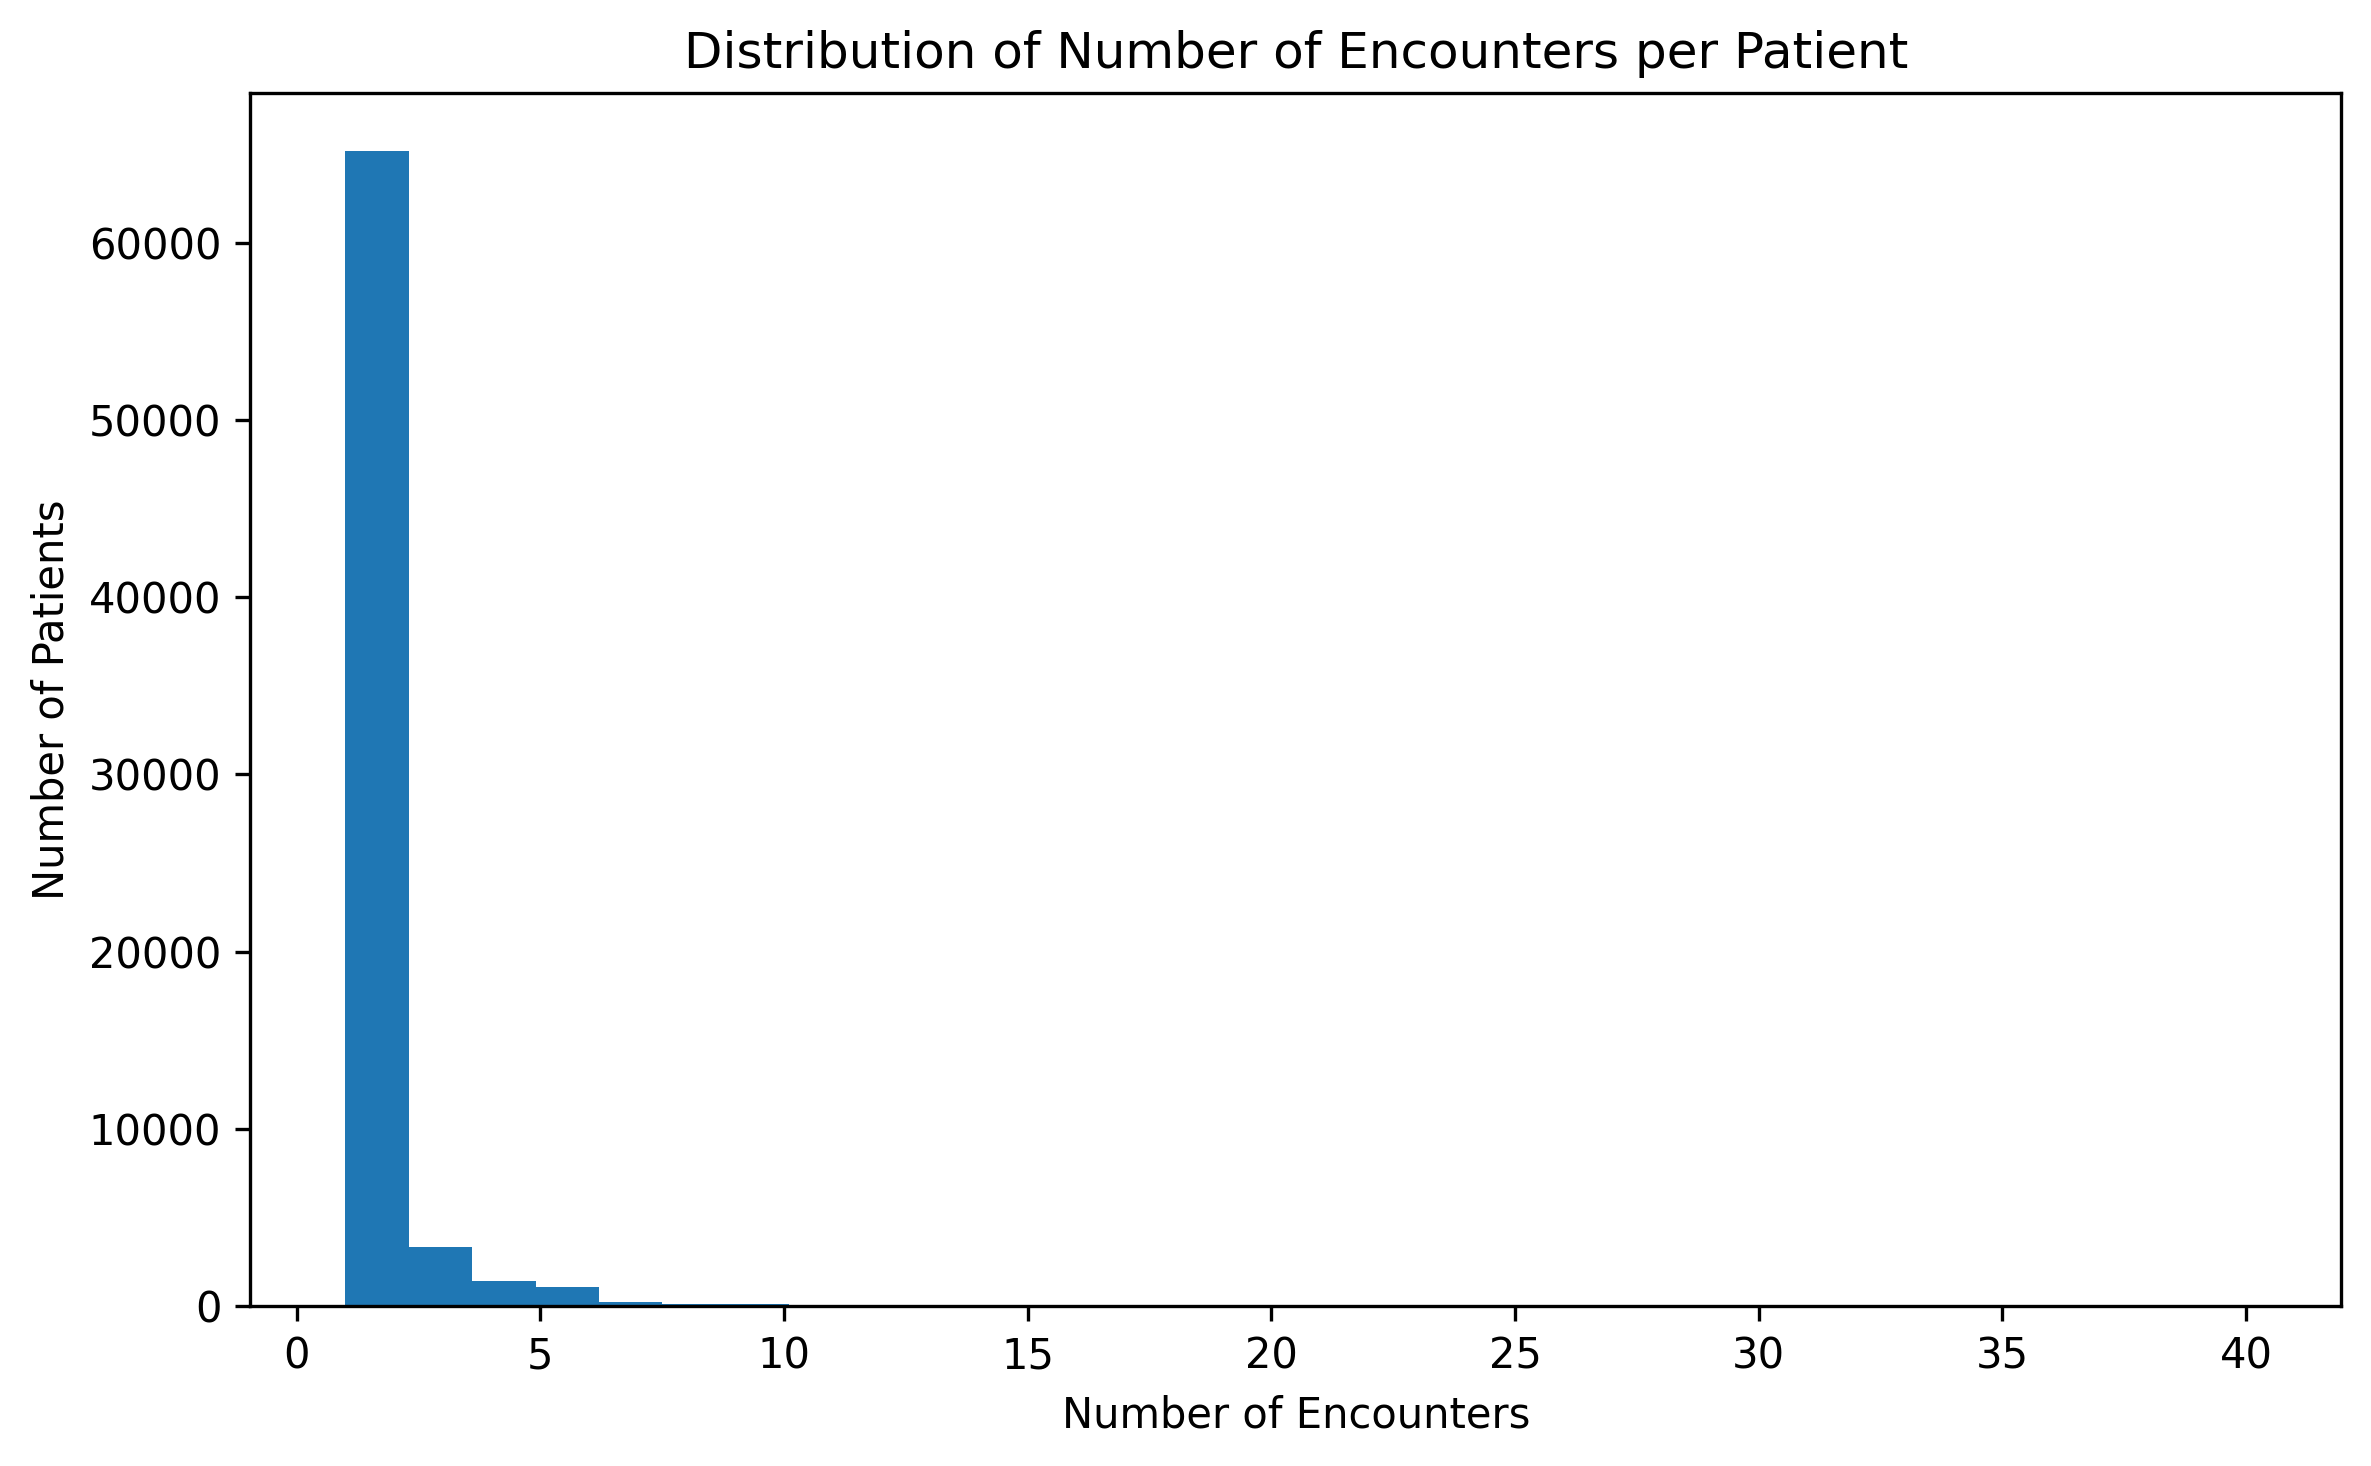


 01_raw_readmission_distribution.png


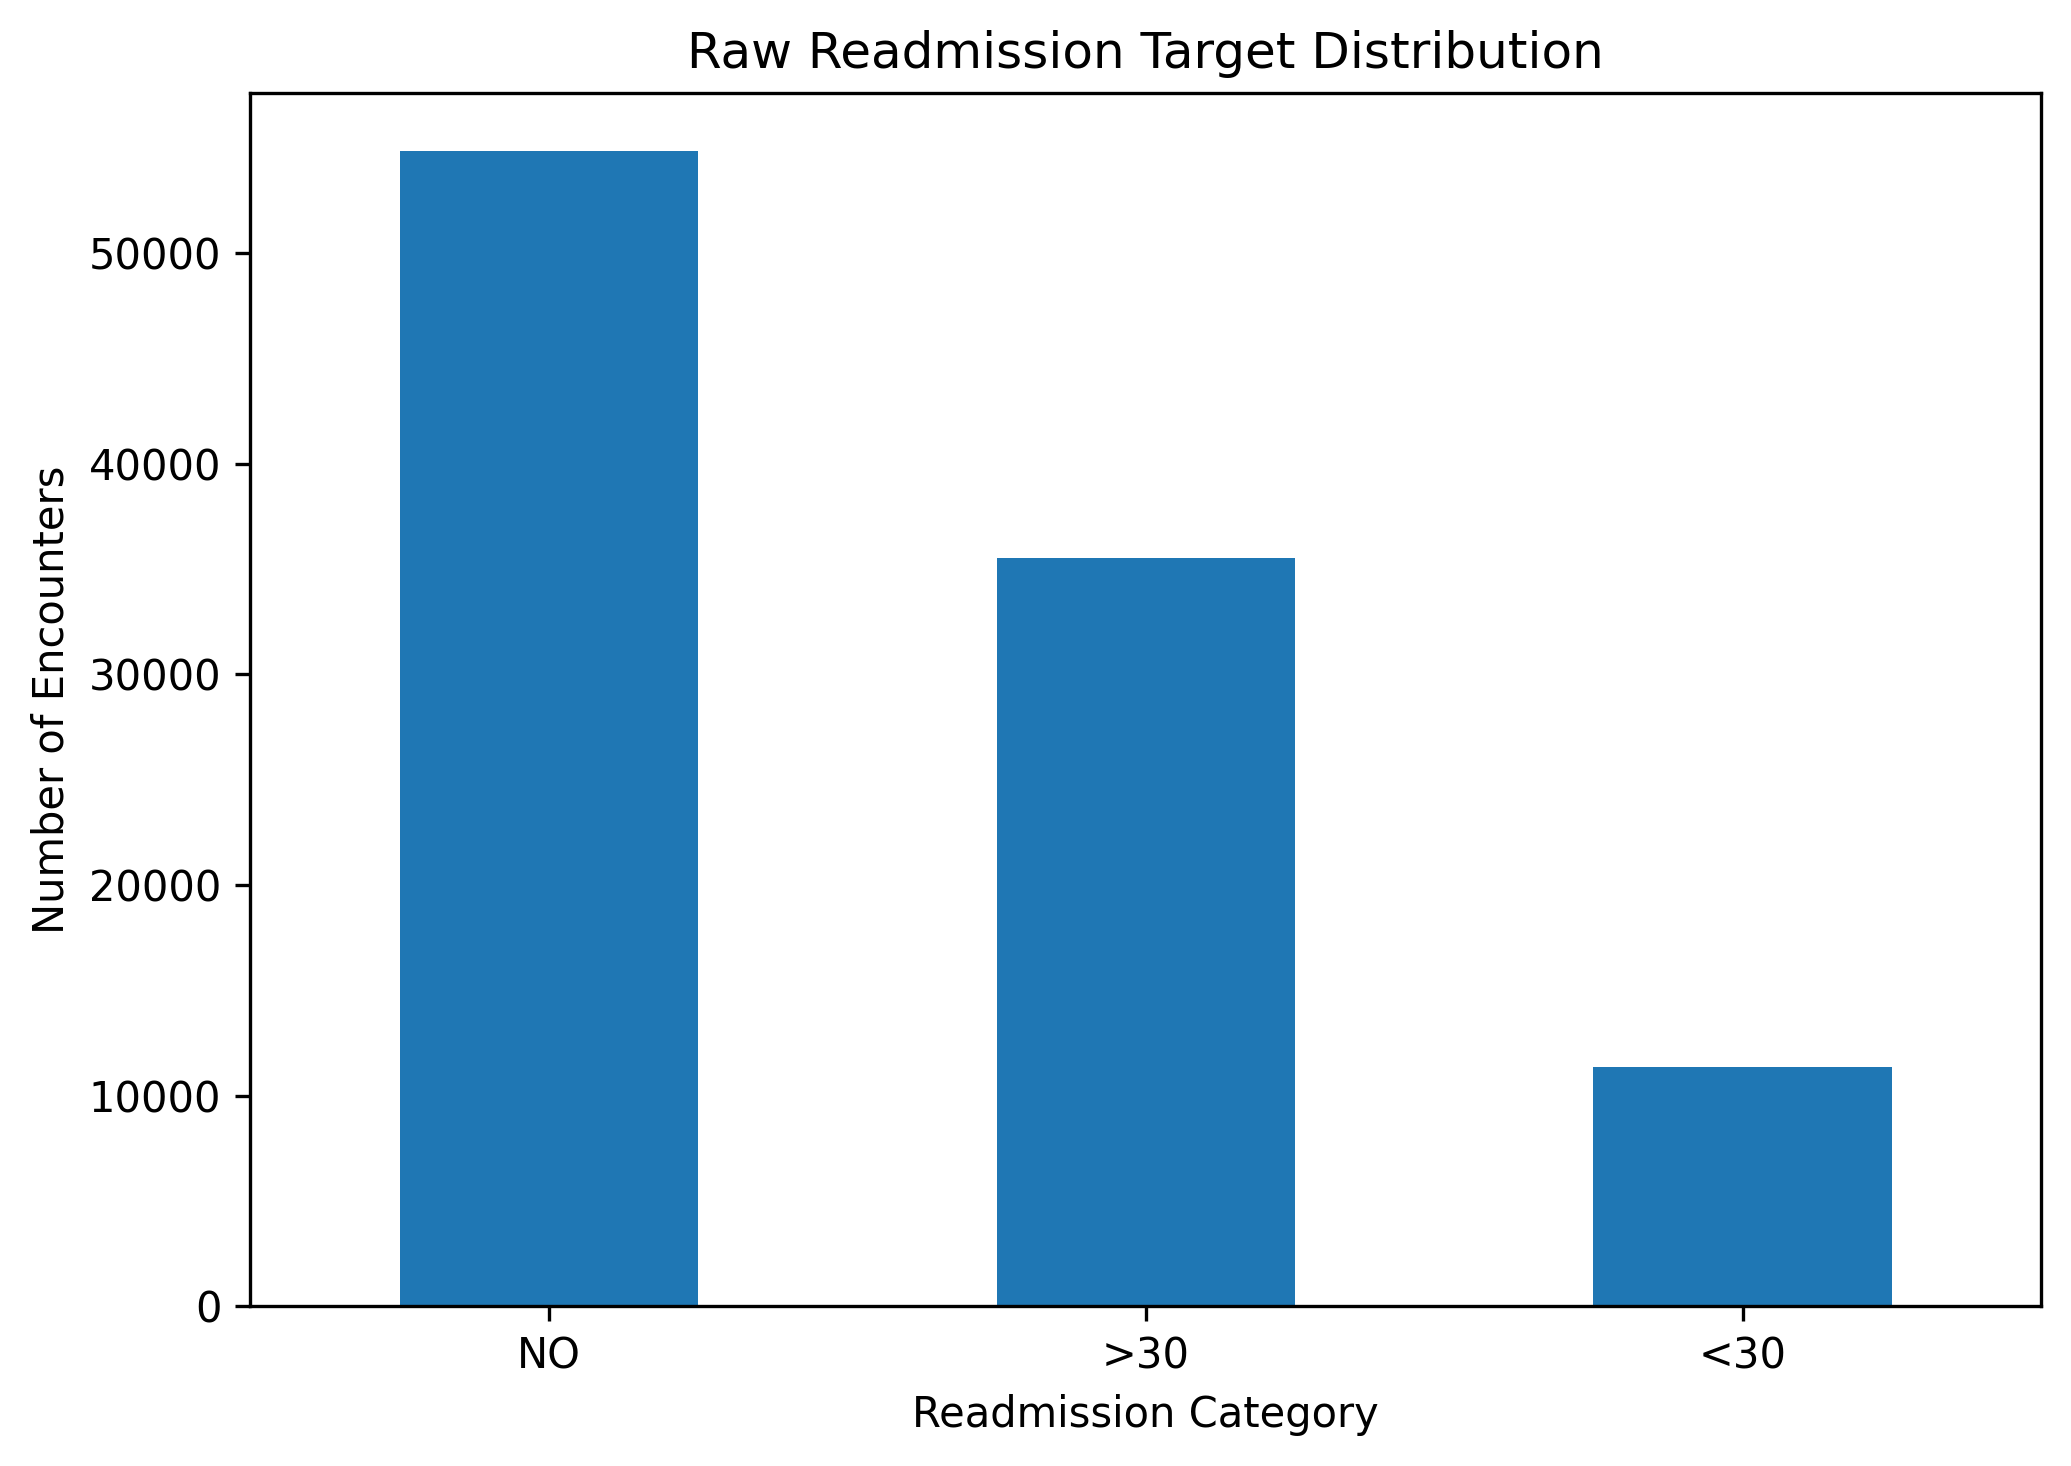


 08_test_calibration.png


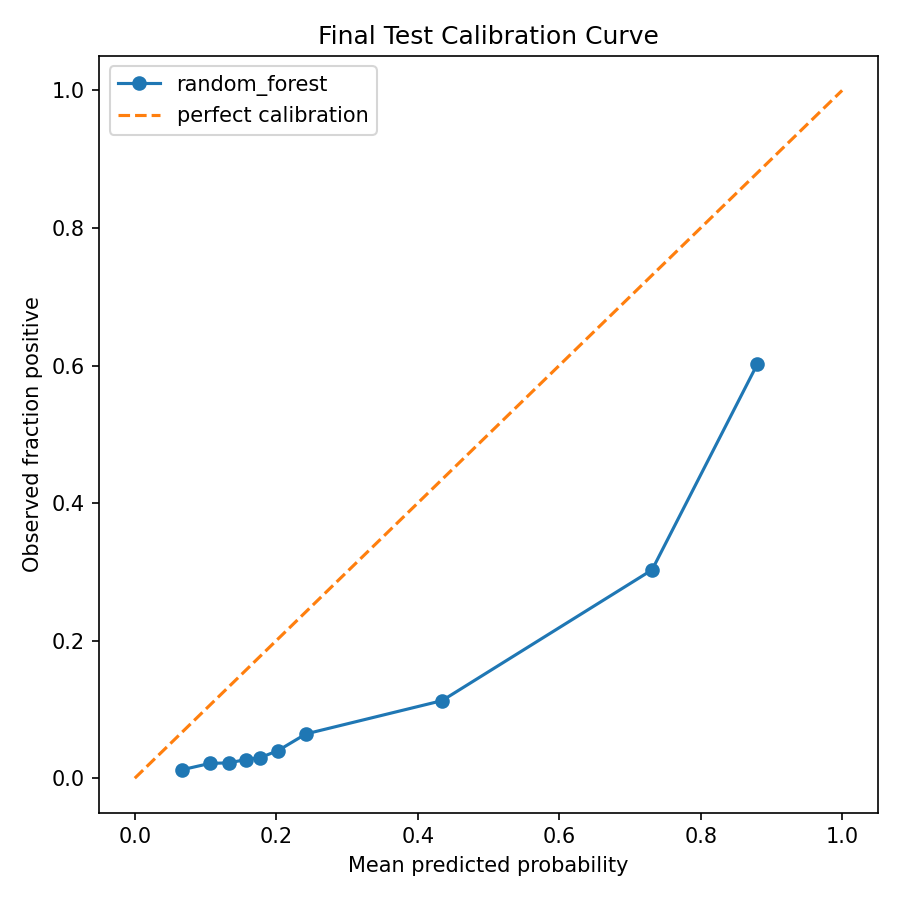


 08_validation_calibration.png


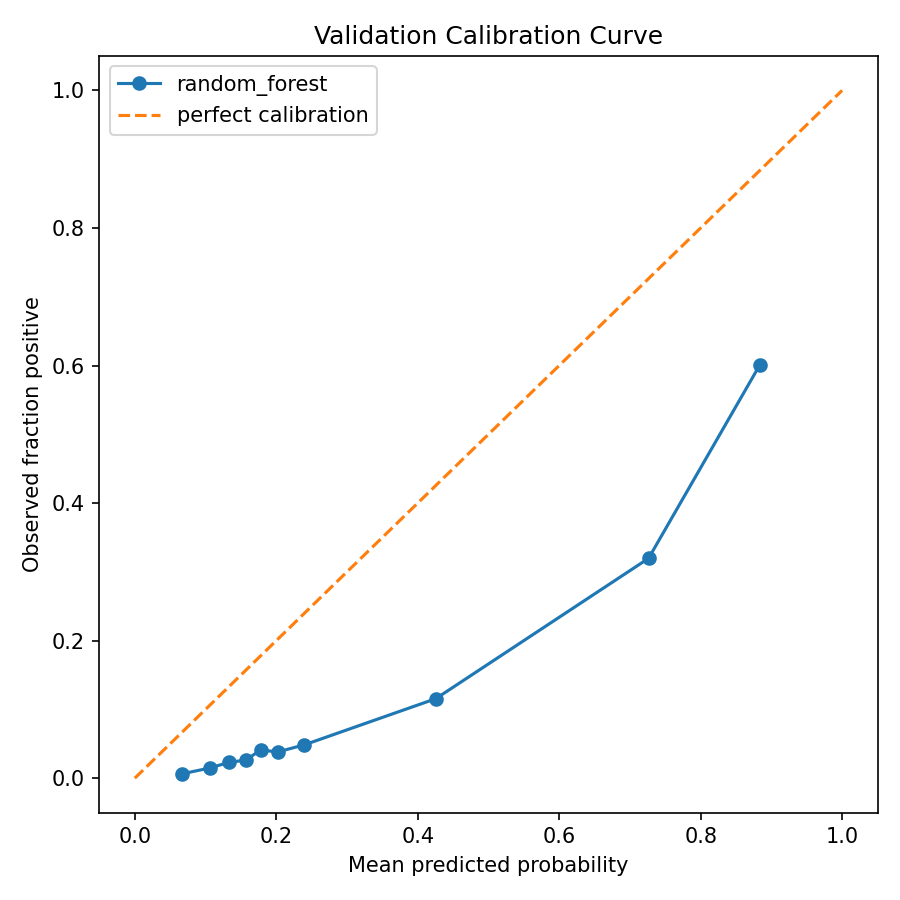


 09_abm_risk_bin_calibration.png


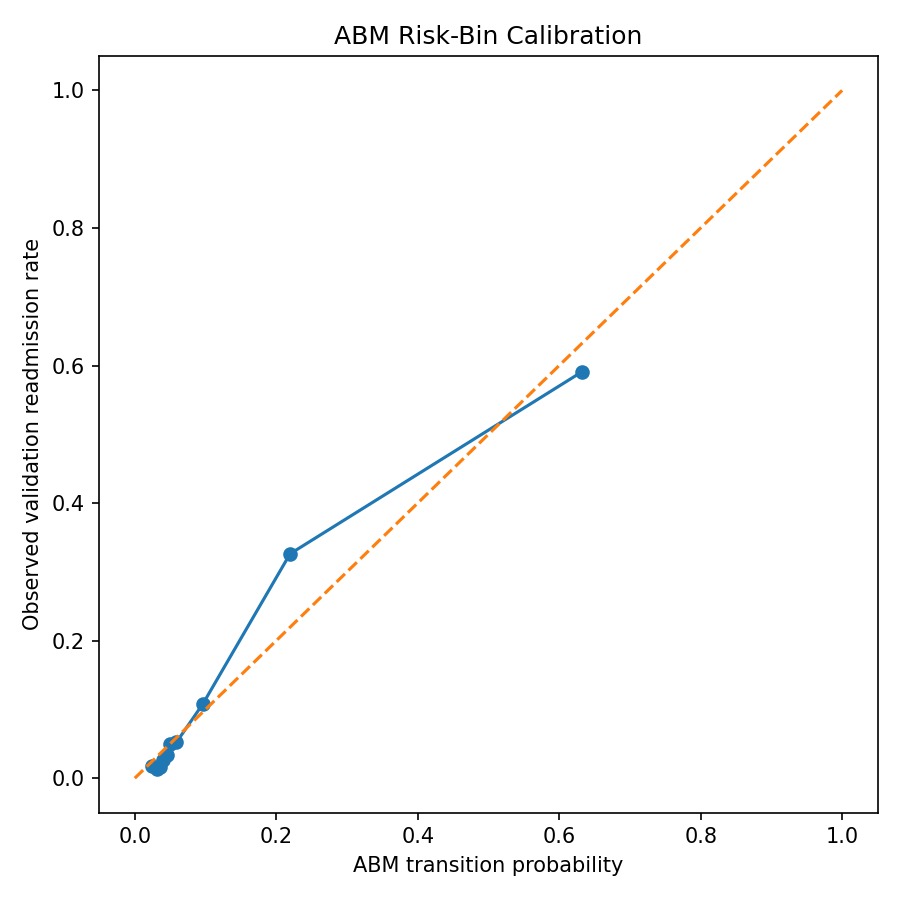


 10_abm_validation_calibration.png


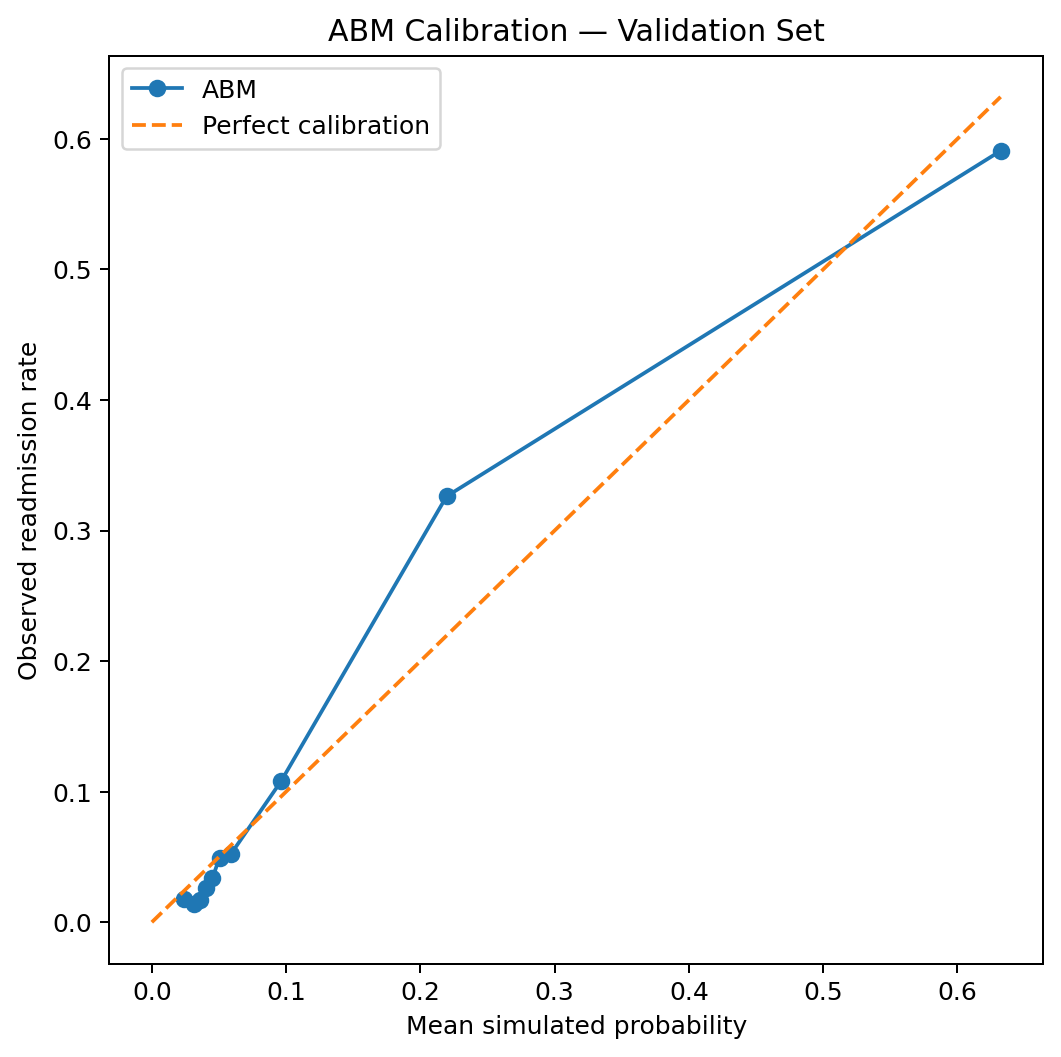


 10_observed_vs_simulated_readmission.png


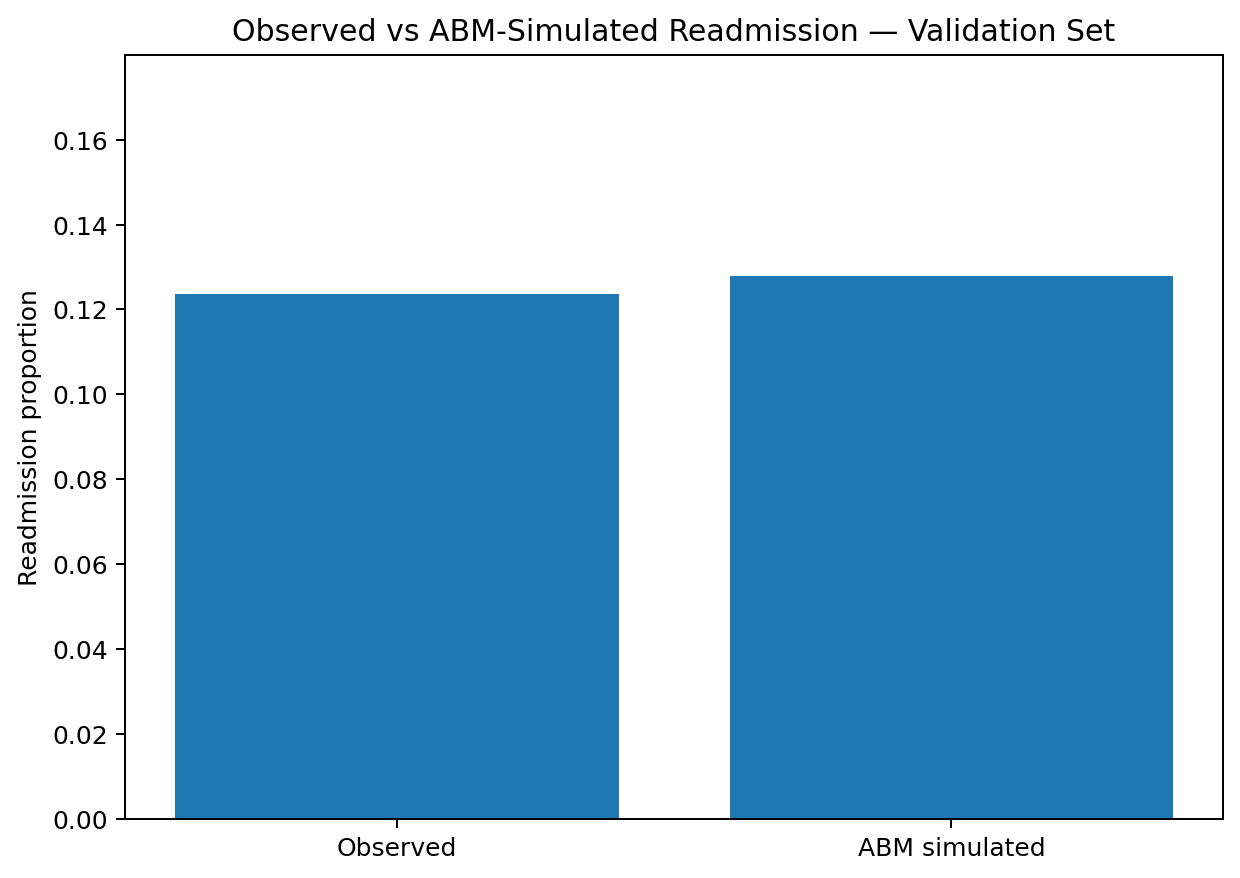


 11_intervention_policy_comparison.png


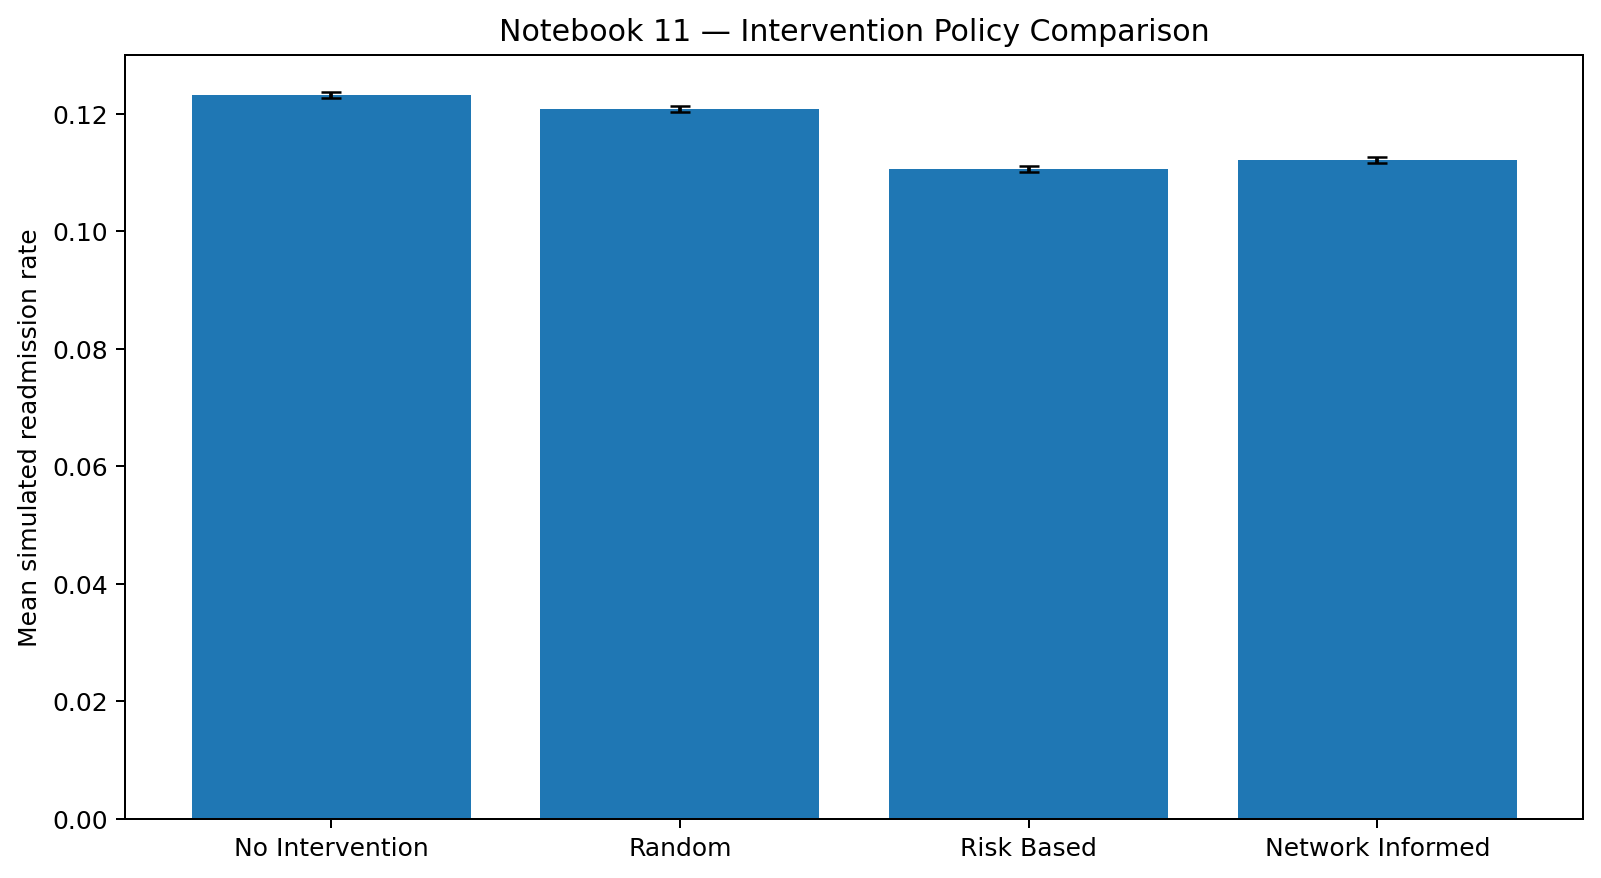


 11_prevented_readmissions.png


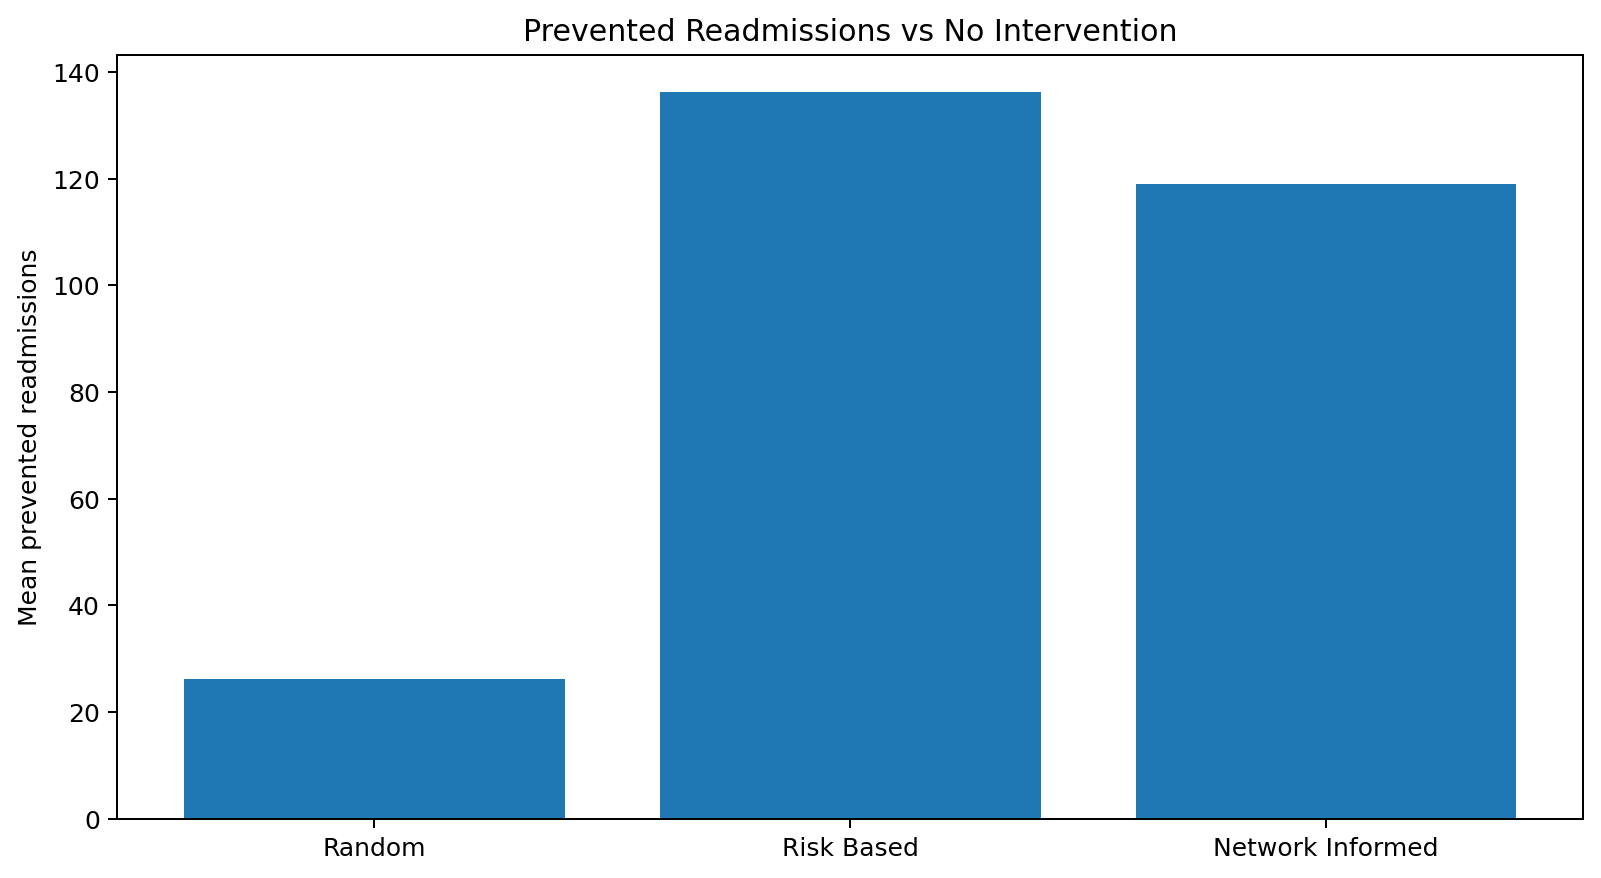


 12_ablation_effects.png


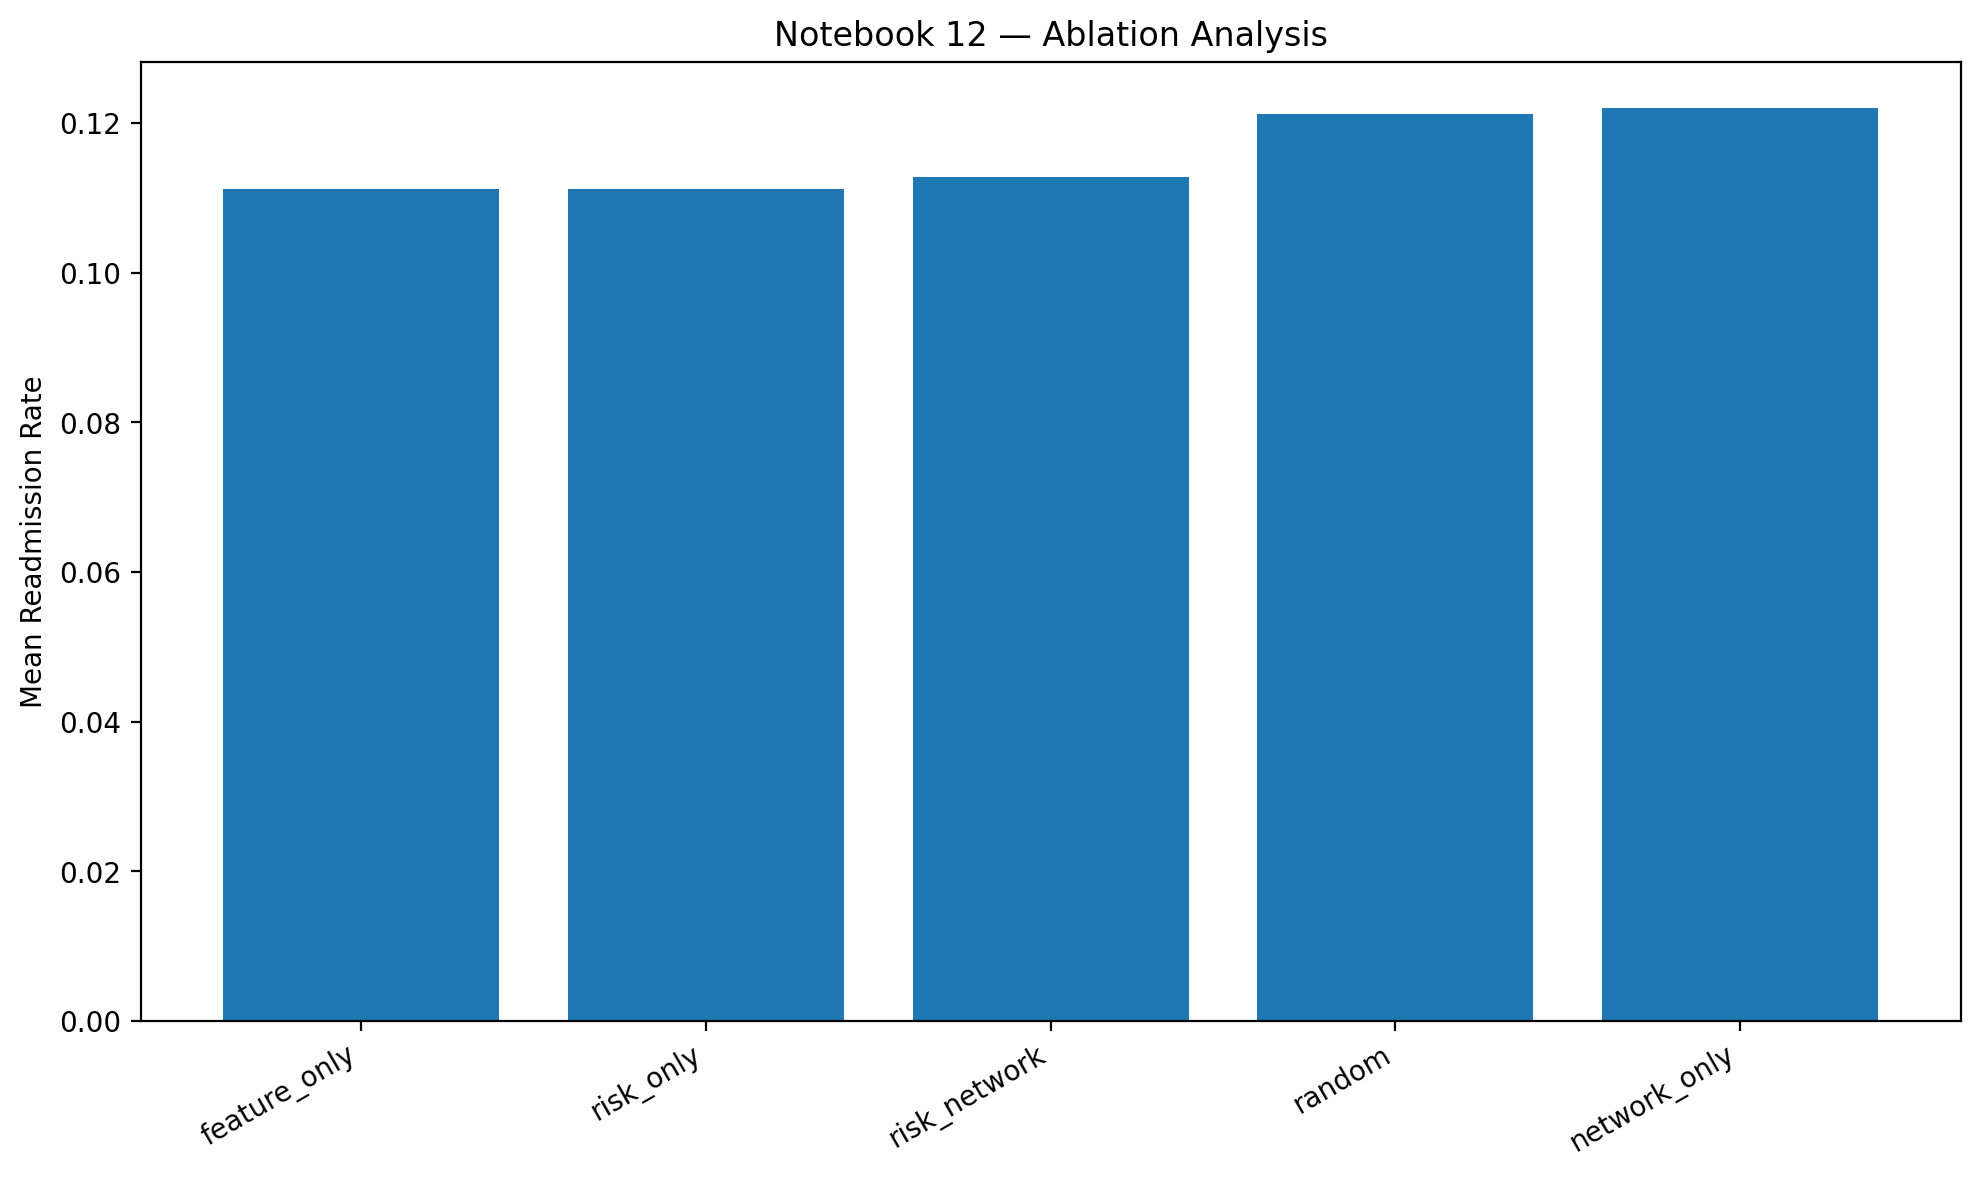


 12_mean_weighted_degree_vs_k.png


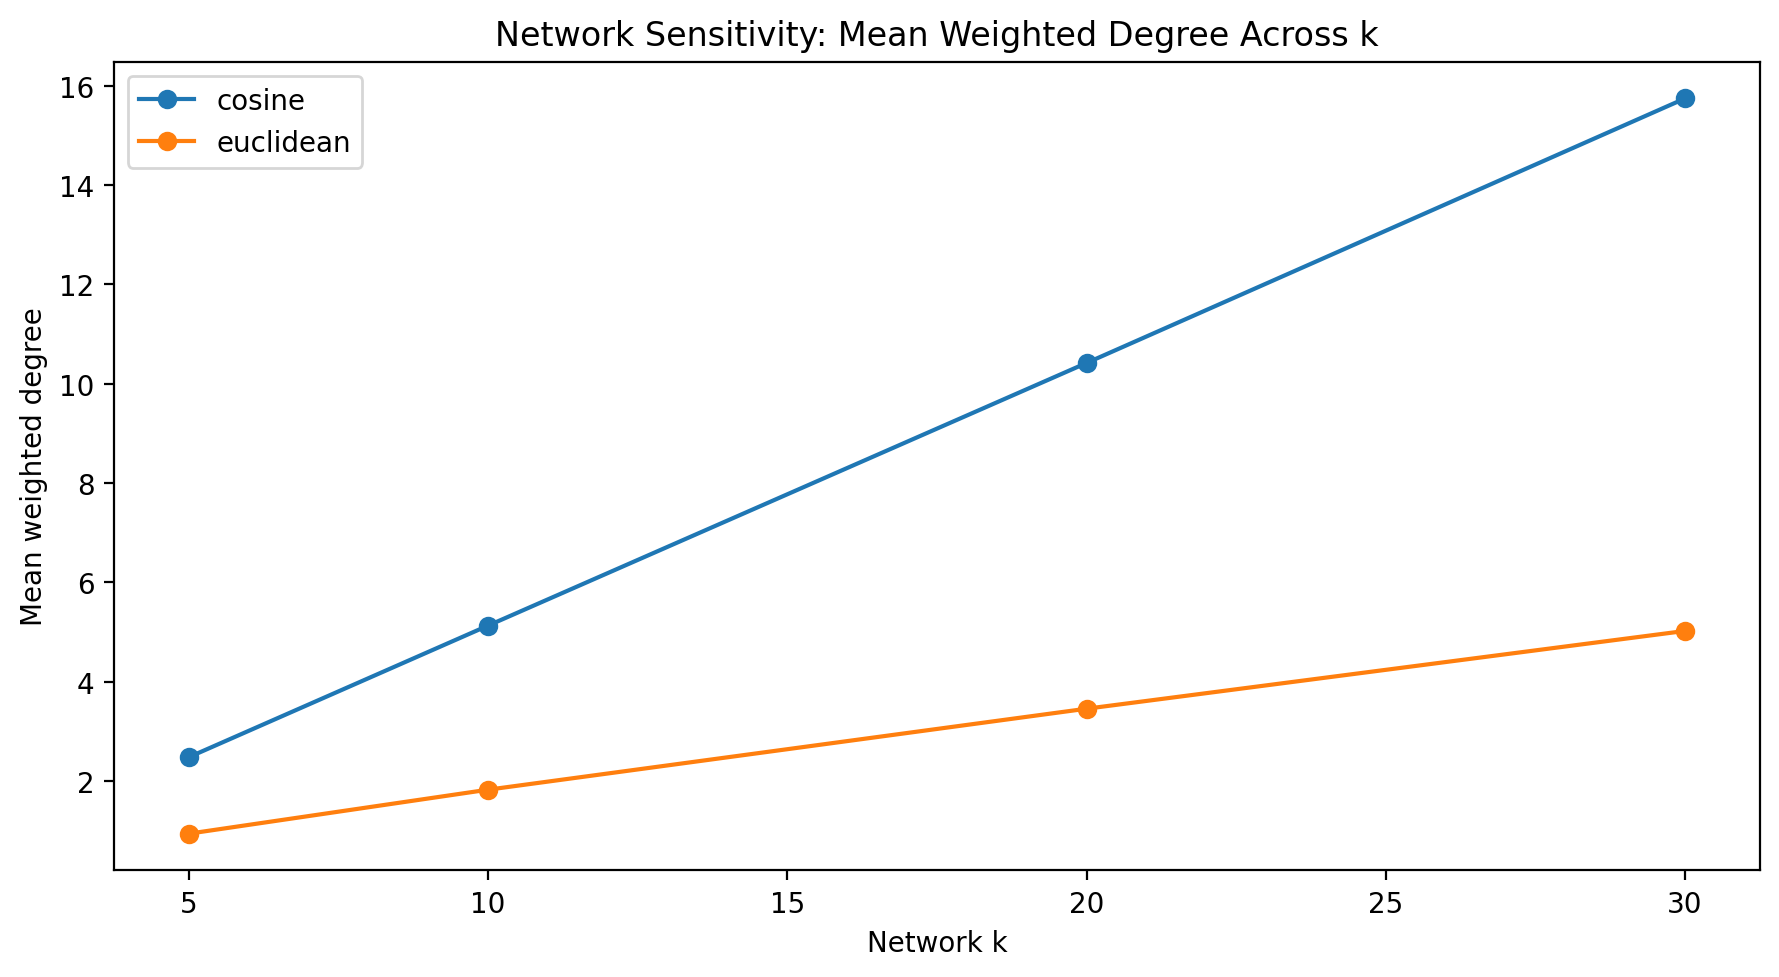


 12_network_density_vs_k.png


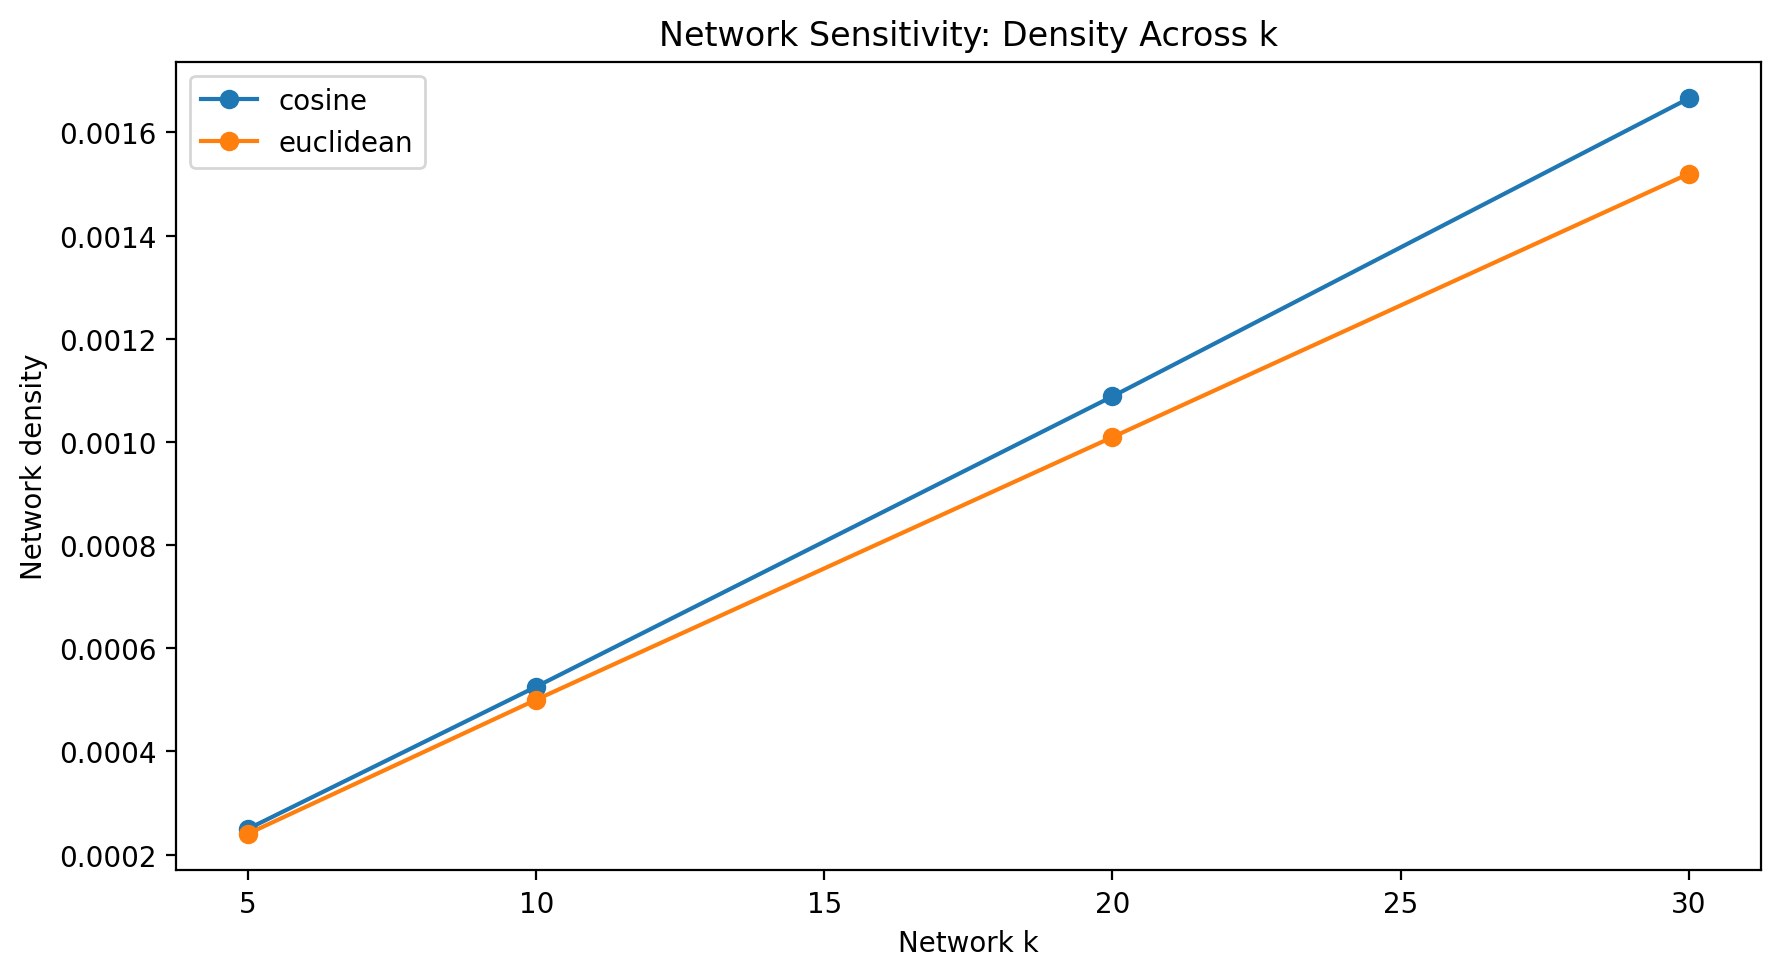


 12_risk_network_robustness_heatmap.png


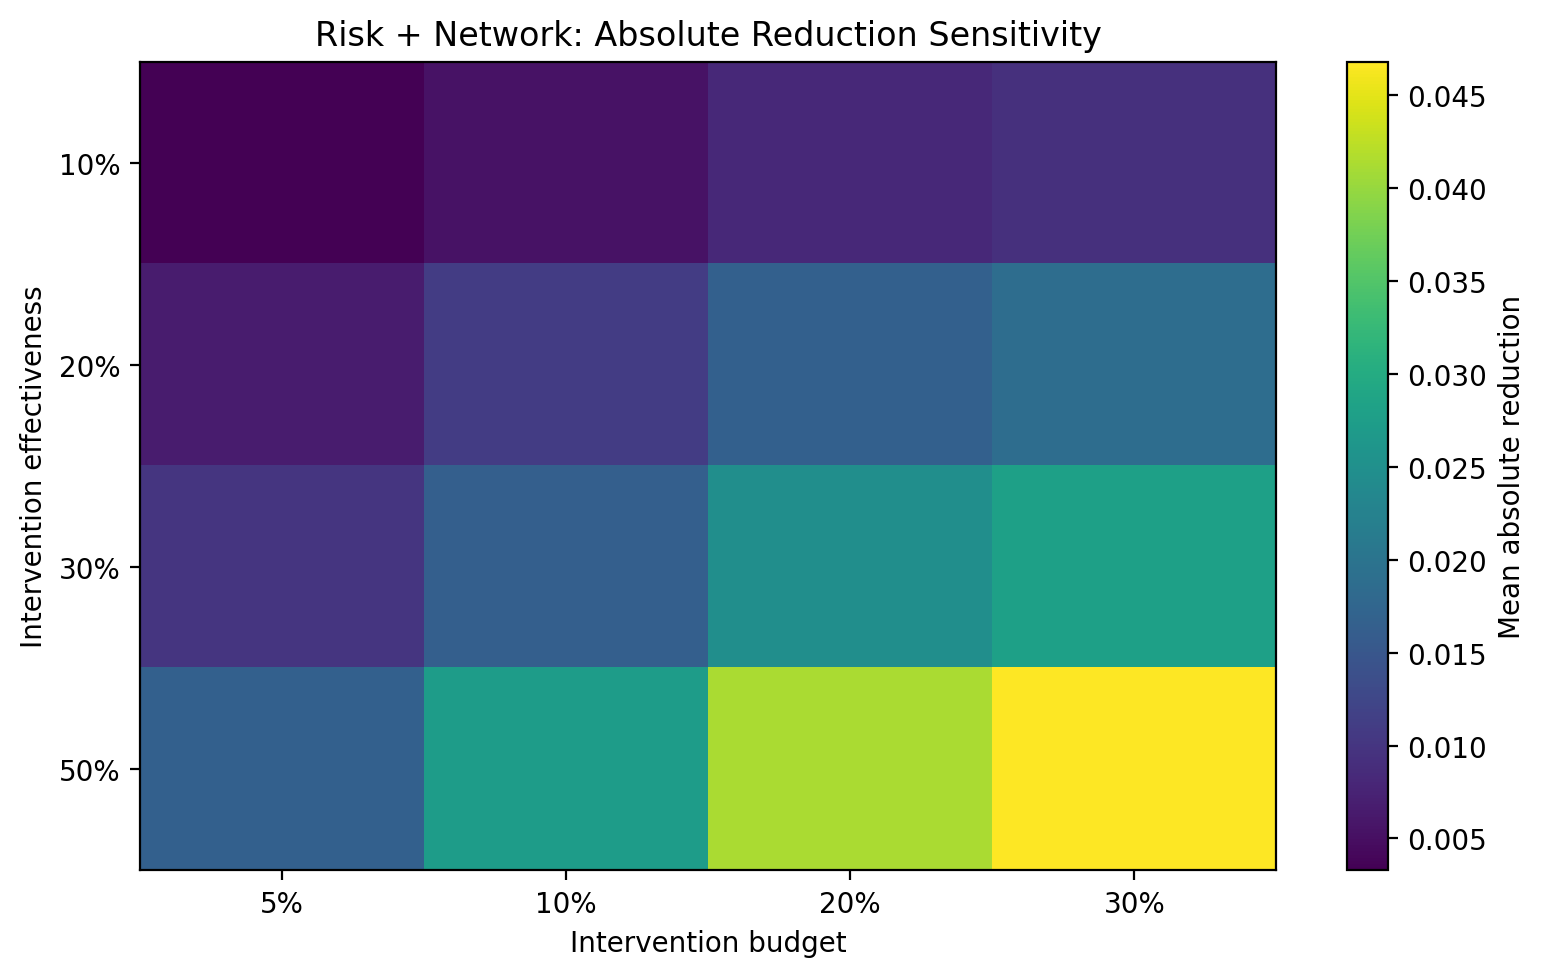


 12_robustness_summary.png


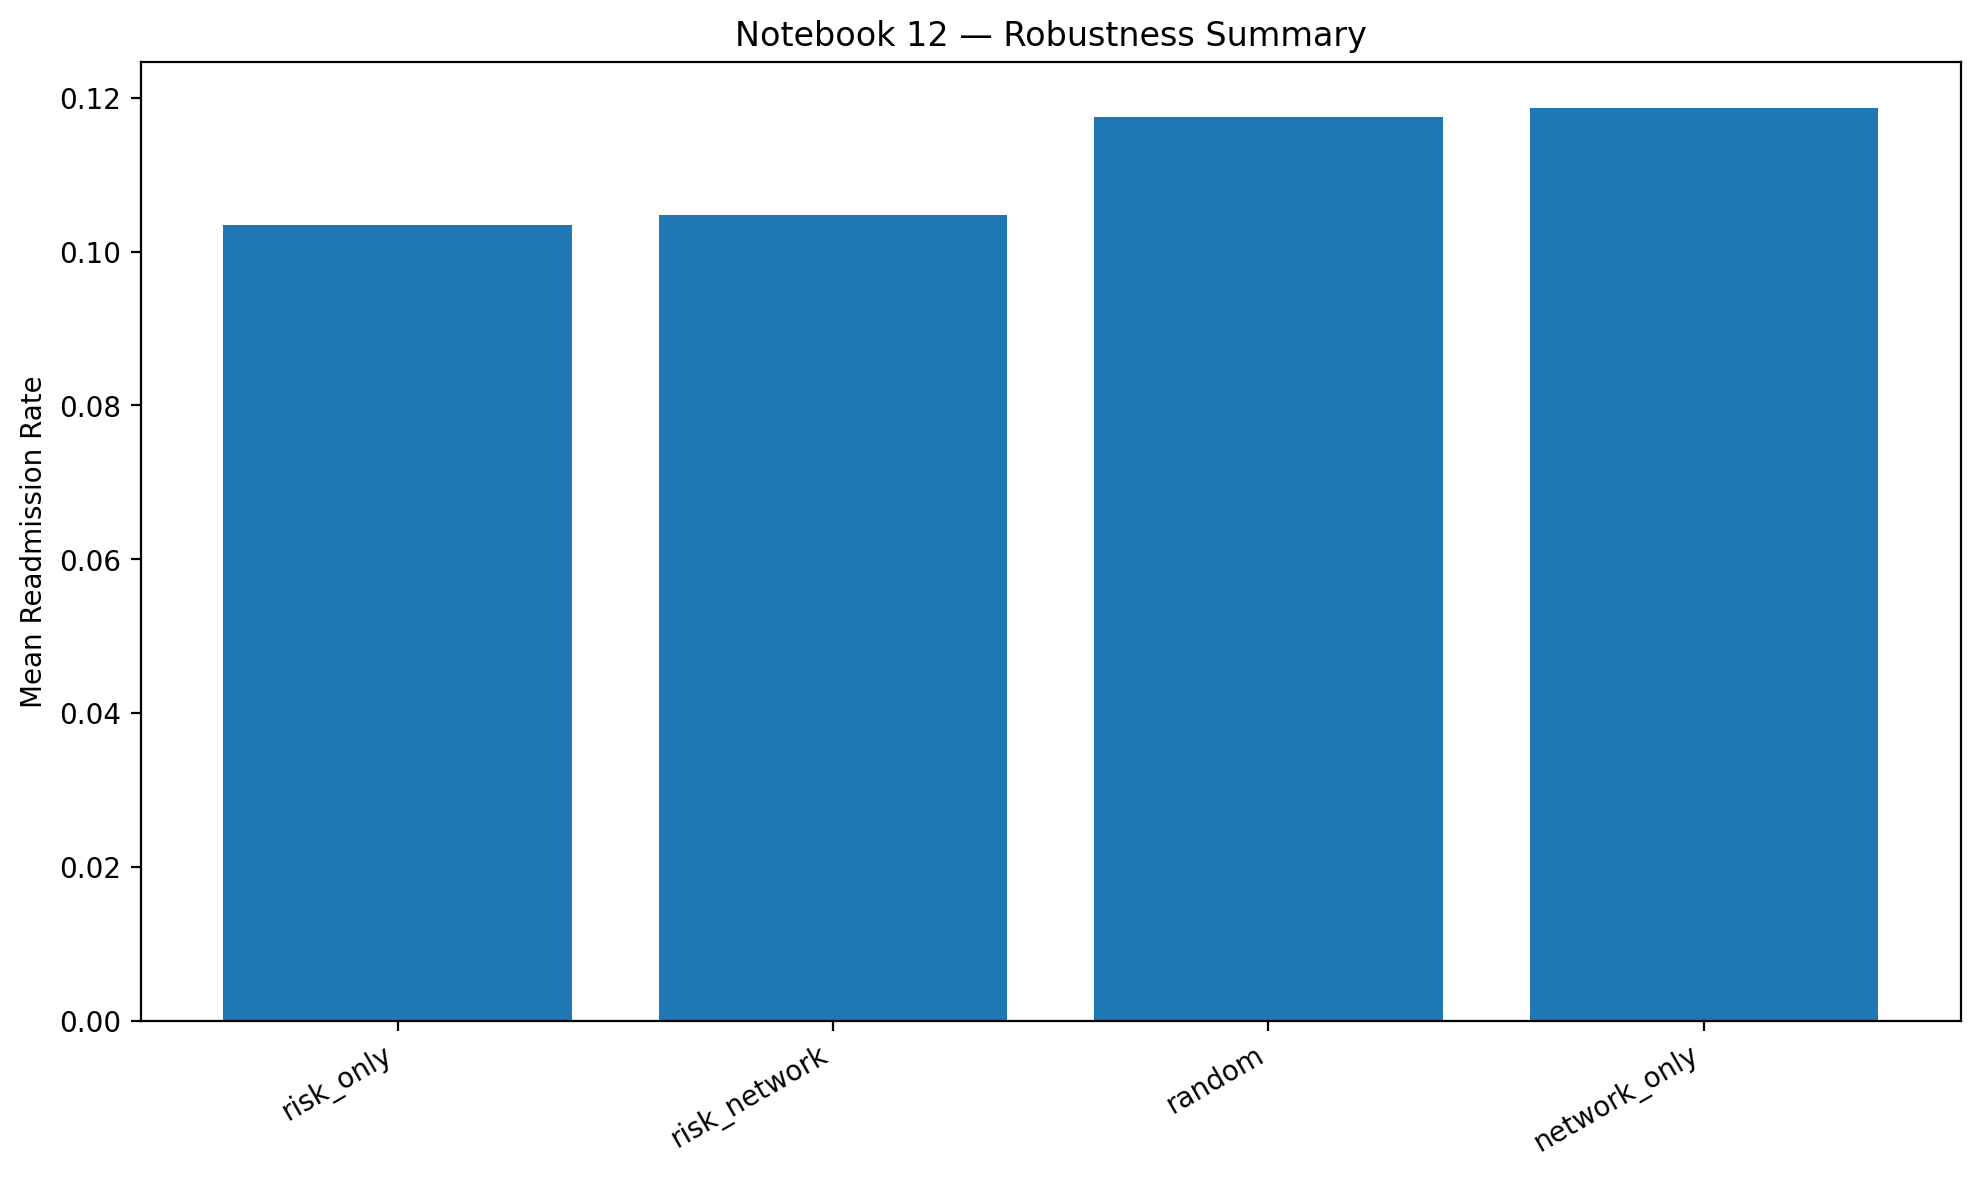


 12_targeting_policy_ablation.png


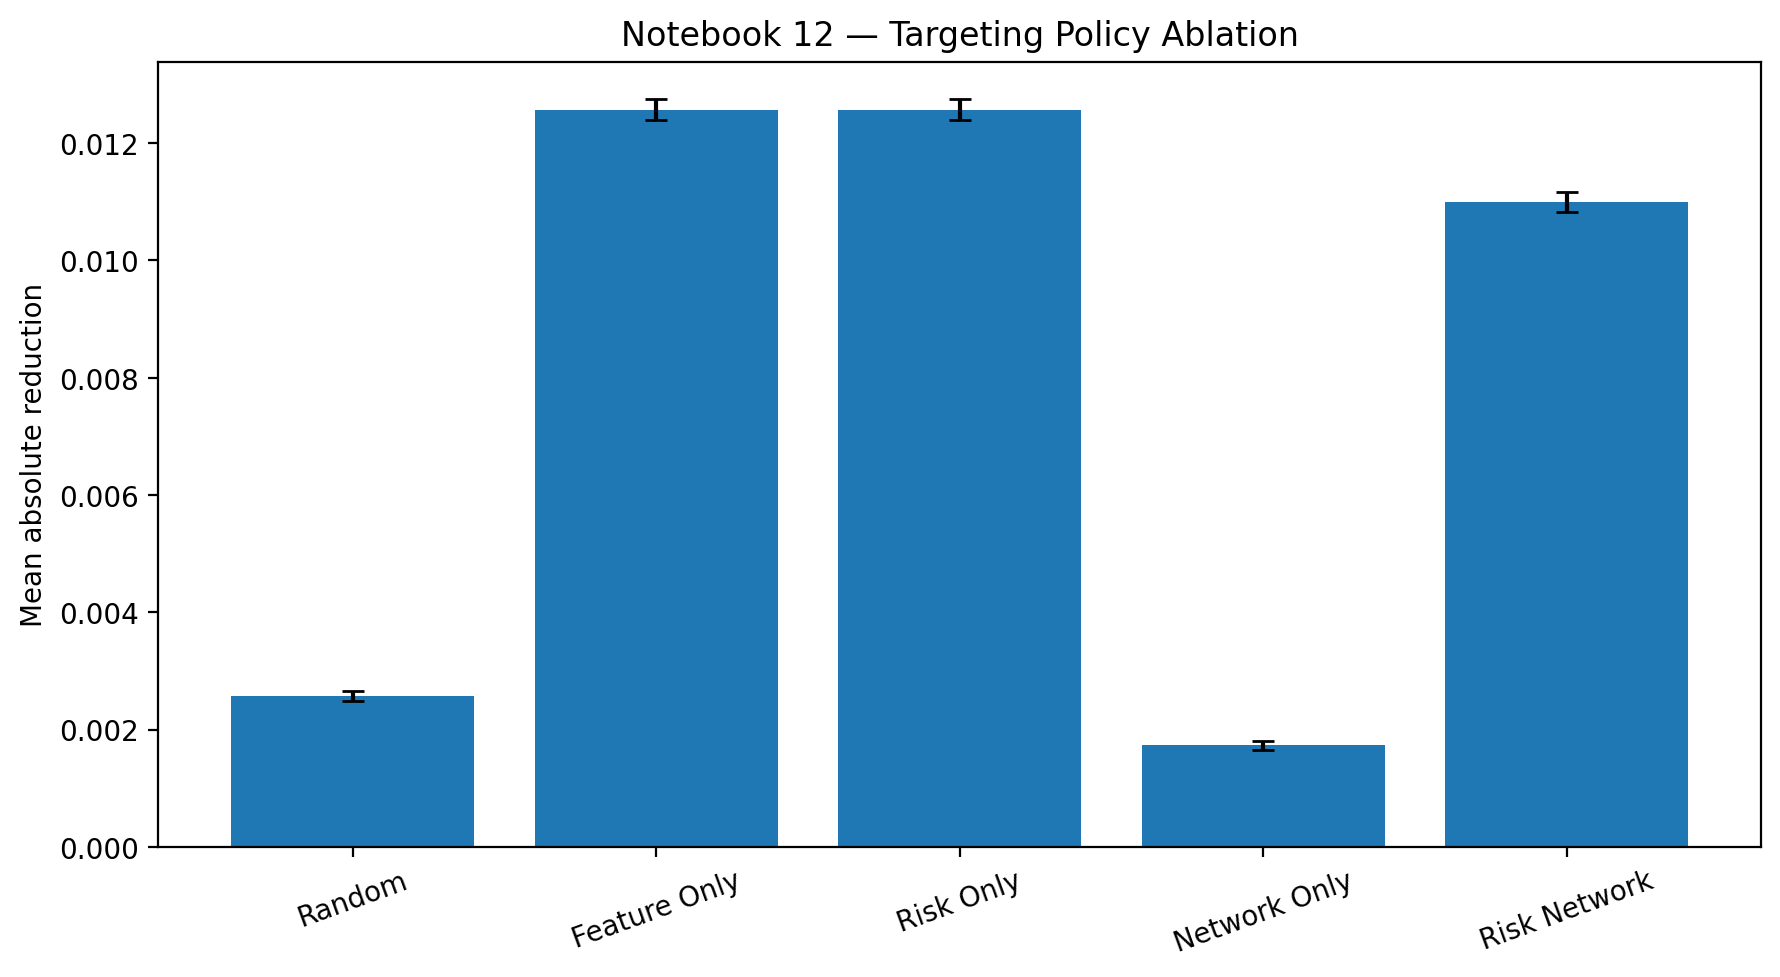

In [24]:
all_figs=sorted(FIGURES.glob("*.png"))
print("Total figures:",len(all_figs))
for p in all_figs:
    print("\n",p.name)
    try: display(Image(filename=str(p)))
    except Exception as e: print("Display error:",e)

# 25. Final Results Inventory

In [25]:
print("="*80)
print("RESULTS")
print("="*80)
for p in sorted(RESULTS.glob("*")):
    print(p.name)

print("\n"+"="*80)
print("FIGURES")
print("="*80)
for p in sorted(FIGURES.glob("*")):
    print(p.name)

RESULTS
01_column_dictionary.csv
01_dataset_audit_summary.json
01_missingness_report.csv
01_reproducibility_config.json
01_target_distribution.csv
02_cleaned_encounters.csv
02_cleaning_summary.json
02_encounter_targets.csv
02_missingness_review.csv
02_variable_selection.csv
03_distribution_summary.csv
03_patient_representation.csv
03_representation_dictionary.csv
03_representation_summary.json
03_target_summary_not_for_features.csv
04_split_leakage_summary.json
04_test_patient_ids.csv
04_test_patients.csv
04_train_patient_ids.csv
04_train_patients.csv
04_validation_patient_ids.csv
04_validation_patients.csv
05_feature_dictionary.csv
05_nearest_neighbor_review.csv
05_similarity_selection.json
05_similarity_summary.json
05_test_feature_patient_ids.csv
05_train_feature_patient_ids.csv
05_validation_feature_patient_ids.csv
05_X_test.npz
05_X_train.npz
05_X_validation.npz
06_network_candidate_stats.csv
06_network_config.json
06_network_summary.json
06_patient_similarity_edges_k10.csv
06_pat